# Gaussian Processes: An Introduction

Gaussian Processes (GPs) are a powerful, flexible tool for regression and classification tasks in machine learning. They model data by defining a probability distribution over functions, allowing for uncertainty quantification and a non-parametric approach to modeling.



Before we dive into Gaussian Processes, let's understand how bayesian modelling works.

### Bayesian Linear Regression

Bayesian Linear Regression provides a probabilistic framework for linear regression by placing priors over the model parameters and computing the posterior distribution given the data.

We assume a **probabilistic** linear model:
$$
y = Xw + \epsilon,
$$
where:
- $ y $ is the vector of observed outputs,
- $ X $ is the design matrix of inputs,
- $ w $ is the vector of weights (parameters),
- $ \epsilon \sim \mathcal{N}(0, \sigma^2) $ is Gaussian noise.

Our goal is to infer the $w$ that maximizes the posterior distribution $p(w | X, y)$. With this, we can construct predictive intervals that complement our initial linear regression fit.



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# Set random seed for reproducibility
np.random.seed(42)

# True parameters for synthetic data generation
true_w = np.array([-2.0, 2.0])  # [w0 (bias), w1 (slope)]
true_sigma = 1  # Noise standard deviation

# Generate synthetic data
X = np.linspace(0, 10, 20)  # Input values
y = true_w[0] + true_w[1] * X + np.random.normal(0, true_sigma, size=X.shape)  # Observations

# Add a bias column to X
X_design = np.vstack([np.ones_like(X), X]).T  # Design matrix with bias

Let's start by visualizing the generated data to understand the problem we are modeling.


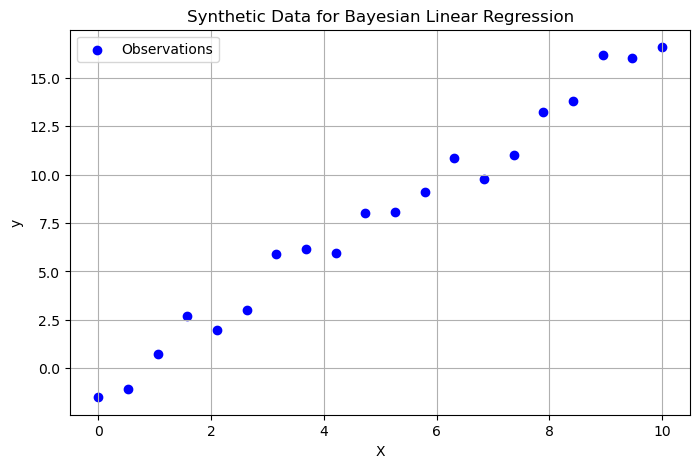

In [3]:
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color="blue", label="Observations")
plt.title("Synthetic Data for Bayesian Linear Regression")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

### Prior Distribution

We assume a Gaussian prior:
$$
p(w) = \mathcal{N}(w_0, \Sigma_0),
$$
where $ w_0 $ is the prior mean, and $ \Sigma_0 $ is the prior covariance matrix.

**Why Gaussian?**
1. The Gaussian distribution is mathematically convenient: its conjugacy with the likelihood ensures that the posterior is also Gaussian.
2. By setting $ w_0 = 0 $, we encode a prior belief that the parameters are centered around zero (i.e., no strong prior information).
3. The prior variance $ \Sigma_0 $ controls our confidence in the prior:
   - Large $ \Sigma_0 $: Weak prior (more weight given to the data).
   - Small $ \Sigma_0 $: Strong prior (less weight given to the data).

For example, with $ \Sigma_0 = \text{diag}([10, 10]) $, we assume high uncertainty about the parameters initially.  Matriz de covarianzas diagonal



In [7]:
# Prior parameters
w0_prior = np.array([0, 0])  # Prior mean
Sigma0_prior = np.diag([10, 10])  # Prior covariance matrix

### Sampling from the Prior

Let's visualize some functions sampled from the prior distribution to understand the variability allowed by the prior.


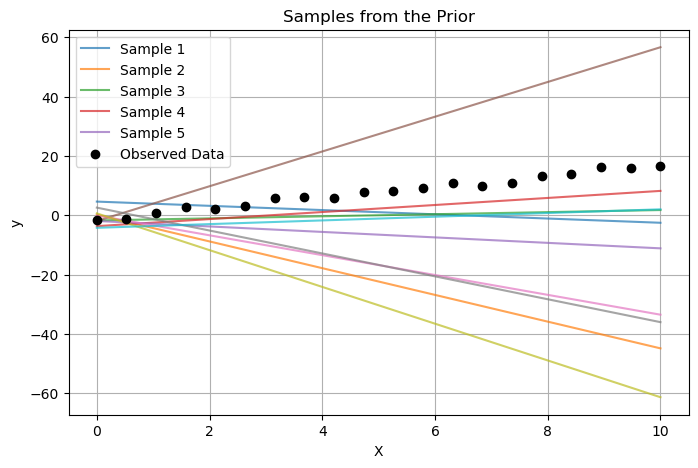

In [10]:
n_samples_prior = 10
# multivariate_normal.rvs genera valores aleatorios (muestras) de una distribución normal multivariante.
w_samples = multivariate_normal.rvs(w0_prior, Sigma0_prior, size=n_samples_prior)

plt.figure(figsize=(8, 5))
for sample in range(n_samples_prior):
    # En cada iteración, seleccionamos una combinación w_0, w_1 de w_samples y construimos la recta:
    y_sampled = w_samples[sample, 0] + w_samples[sample, 1] * X
    plt.plot(X, y_sampled, alpha=0.7, label=f"Sample {sample+1}" if sample < 5 else None)

plt.scatter(X, y, color="black", label="Observed Data", zorder=5)
plt.title("Samples from the Prior")
plt.xlabel("X")
plt.ylabel("y")
plt.grid(True)
plt.legend()
plt.show()


#### Ninguna de las regresiones lineales van bien. Vamos a hallar las omegas que maximizan la verosmilitud dadas las entradas.

### Likelihood Function

Assume the data follows: (Multiplicación de matrices)
$$
y_i \sim \mathcal{N}(w^T x_i, \sigma^2), \quad i = 1, \dots, n.
$$
The joint likelihood for all $ n $ data points is: (multiplicación porque es la probabilidad de varios puntos)
$$
p(y \mid X, w) = \prod_{i=1}^n \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(y_i - w^T x_i)^2}{2\sigma^2}\right).
$$
Taking the logarithm for computational simplicity: (ya que lo de arriba son numeros entre 0 y 1 y si no empieza a desvanecerse)
$$
\log p(y \mid X, w) = -\frac{n}{2} \log(2\pi\sigma^2) - \frac{1}{2\sigma^2} \sum_{i=1}^n (y_i - w^T x_i)^2.
$$
This simplifies to: (Se llega al RMSE)
$$
\log p(y \mid X, w) \propto -\frac{1}{2\sigma^2} ||y - Xw||_2^2.
$$

### Posterior Distribution

Using Bayes' rule:
$$
p(w \mid X, y) \propto p(y \mid X, w) \, p(w).
$$

The likelihood is:
$$
\log p(y \mid X, w) \propto -\frac{1}{2\sigma^2} ||y - Xw||_2^2.
$$

The prior is:
$$
\log p(w) \propto -\frac{1}{2} (w - w_0)^T \Sigma_0^{-1} (w - w_0).
$$

Combining terms:
$$
\log p(w \mid X, y) \propto -\frac{1}{2} \left[ (y - Xw)^T (y - Xw) / \sigma^2 + (w - w_0)^T \Sigma_0^{-1} (w - w_0) \right].
$$

Completing the square:
$$
p(w \mid X, y) = \mathcal{N}(w_N, \Sigma_N),
$$
where: (Reglas de actualización (en este caso, es lo mismo que OLS)). Queremos que la media se parezca lo mas posible a mi salida
$$
\Sigma_N = \left(\Sigma_0^{-1} + \frac{1}{\sigma^2} X^T X\right)^{-1},
$$
$$
w_N = \Sigma_N \left(\Sigma_0^{-1} w_0 + \frac{1}{\sigma^2} X^T y\right).
$$



Resumen del proceso:

1.	Generación inicial de parámetros (prior):
    
- Se define una distribución prior para los parámetros w = (w_0, w_1), que refleja nuestras creencias iniciales antes de observar datos.
- Se genera un grid de valores para evaluar tanto la verosimilitud como el posterior en toda la región plausible de w_0 y w_1.

	2.	Evaluación de la verosimilitud para un punto (x_i, y_i):
  
- Para un punto de datos fijo, calculamos la verosimilitud en el grid de parámetros.
- Esto indica qué tan probable es que el modelo, con parámetros específicos del grid, haya generado el punto observado.
	3.	Actualización del posterior:
- Se combina el prior con la verosimilitud para calcular la distribución posterior. Esto se realiza mediante:

$p(w | \text{data}) \propto p(w) \cdot p(\text{data} | w)$

- El posterior ahora refleja nuestras creencias actualizadas sobre w_0 y w_1.

	4.	Uso del posterior como prior para el siguiente punto:

- La posterior obtenida después de observar el punto (x_i, y_i) se convierte en el nuevo prior para el siguiente punto.
- Repetimos el proceso para todos los puntos en el conjunto de datos.


	5.	Generación de muestras del posterior:

- Desde la distribución posterior actualizada, se generan n_{\text{samples}} combinaciones de w_0, w_1 (estas muestras se usan principalmente para visualizar las funciones lineales resultantes, no para calcular la verosimilitud del siguiente punto).
- La evaluación de la verosimilitud para el siguiente punto no depende de estas muestras, sino que se realiza sobre el mismo grid fijo de parámetros.

Imaginamos que tienes un punto de datos (x_i, y_i):
- x_i = 2, y_i = 5
- Pruebas w_0 desde -3.5 a 3.5 y w_1 desde -3.5 a 3.5.
- Si w_0 = 1 y w_1 = 2, la predicción sería:

$y_{\text{pred}} = 1 + 2 \cdot 2 = 5$

Esto coincide perfectamente con y_i = 5, así que esta combinación de pesos tendría una alta verosimilitud.
- Si w_0 = -1 y w_1 = 0.5, la predicción sería:

$ y_{\text{pred}} = -1 + 0.5 \cdot 2 = 0$

Esto está muy lejos de y_i = 5, y esa combinación tendría una verosimilitud muy baja.

Al final, evaluamos todas las combinaciones de w_0 y w_1 para identificar las más plausibles según los datos observados.

In [13]:
def compute_likelihood(w_grid, x_i, y_i, sigma2):
    """Compute the likelihood for a grid of weights given one data point."""
    likelihood = np.zeros(w_grid.shape[:2])
    for i in range(w_grid.shape[0]):
        for j in range(w_grid.shape[1]):
            w = w_grid[i, j, :]
            y_pred = x_i @ w
            likelihood[i, j] = np.exp(-0.5 * (y_i - y_pred)**2 / sigma2) / np.sqrt(2 * np.pi * sigma2)
    return likelihood

We will generate a grid of weights to evaluate the distributions and see its changes from prior to posterior

In [16]:
# Define the weight grid
w0_range = np.linspace(-3.5, 3.5, 100)
w1_range = np.linspace(-3.5, 3.5, 100)
w0_grid, w1_grid = np.meshgrid(w0_range, w1_range)
w_grid = np.dstack((w0_grid, w1_grid))

# Compute the prior
prior = multivariate_normal.pdf(w_grid, mean=w0_prior, cov=Sigma0_prior)

### Point-wise updates

Thanks to the iterative approach to Bayes, we can actually perform this point-by-point to see the progress the model makes in each case. We will update the model with a single point and include the next one later on...

In [18]:
# Select a single data point
i = 10  # Select one data point
x_i = X_design[i, :]  # Design matrix row for this point
y_i = y[i]  # Corresponding output value

# Compute the likelihood for the selected point
sigma2 = true_sigma**2
likelihood = compute_likelihood(w_grid, x_i, y_i, sigma2 = sigma2)

# Compute the posterior (proportional to prior * likelihood)
posterior = prior * likelihood
posterior /= np.sum(posterior)  # Normalize for visualization

# Compute the posterior covariance for the single-point update
Sigma_N = np.linalg.inv(
    np.linalg.inv(Sigma0_prior) + (1 / sigma2) * np.outer(x_i, x_i)
)

# Compute the posterior mean for the single-point update
w_N = Sigma_N @ (
    np.linalg.inv(Sigma0_prior) @ w0_prior + (1 / sigma2) * x_i * y_i
)

We now visualize the step-by-step Bayesian updates to the posterior using one data point at a time.


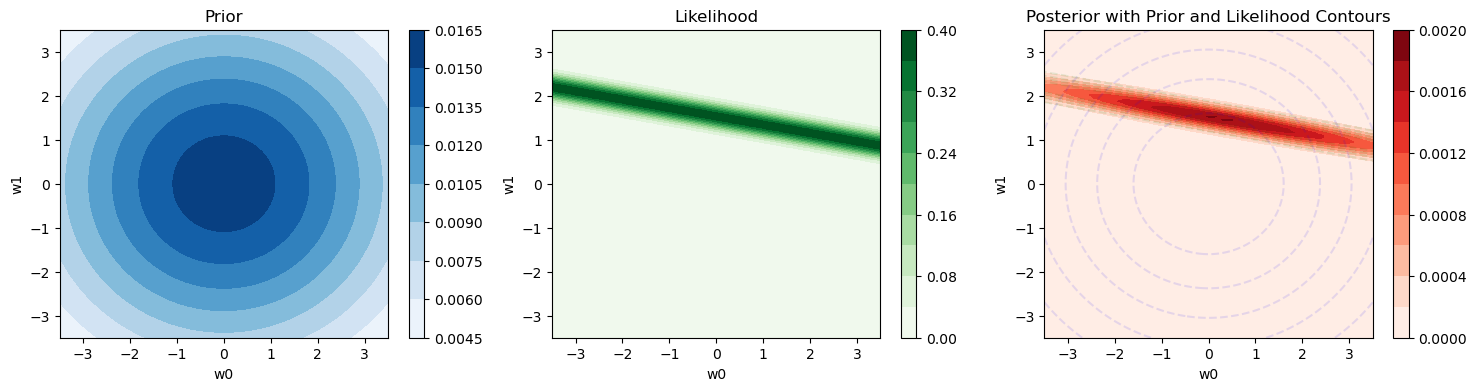

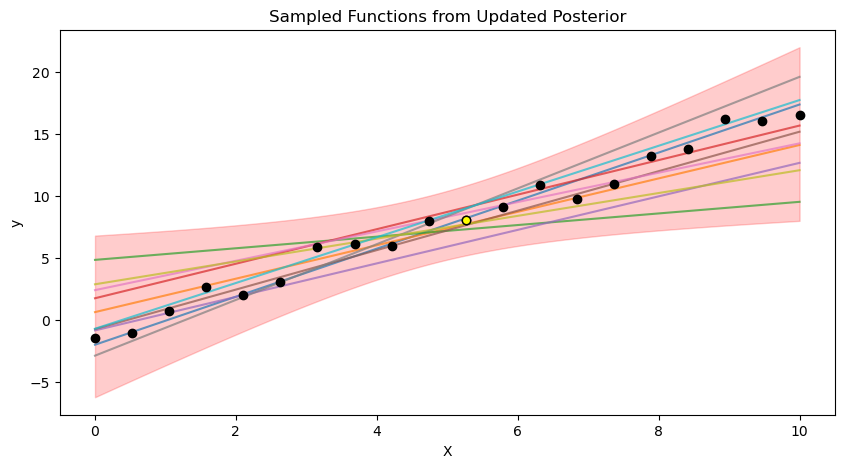

In [21]:
########### Saltamos de las gráficas a lo siguiente:
########### n_samples especifica cuántas combinaciones de w_0, w_1 se generan desde la distribución posterior

#w \sim \mathcal{N}(\text{mean} = w_N, \text{cov} = \Sigma_N)


def plot_updates(prior, likelihood, posterior, point_selected, w0_grid = w0_grid, w1_grid = w1_grid, 
                means = w_N, covs = Sigma_N, n_samples = 10):

    # Sample functions from the new posterior
    w_posterior_samples_new = multivariate_normal.rvs(mean=means, cov=covs, size=n_samples)

    # Plot prior, likelihood, posterior, and updated posterior
    plt.figure(figsize=(18, 4))

    # Plot the prior
    plt.subplot(1, 3, 1)
    plt.contourf(w0_grid, w1_grid, prior, levels=10, cmap="Blues")
    plt.colorbar()
    plt.title("Prior")
    plt.xlabel("w0")
    plt.ylabel("w1")
    
    # Plot the new likelihood
    plt.subplot(1, 3, 2)
    plt.contourf(w0_grid, w1_grid, likelihood, levels=10, cmap="Greens")
    plt.colorbar()
    plt.title("Likelihood")
    plt.xlabel("w0")
    plt.ylabel("w1")

    # Plot the updated posterior
    plt.subplot(1, 3, 3)
    plt.contourf(w0_grid, w1_grid, posterior, levels=10, cmap="Reds", alpha=1)
    plt.colorbar()
    plt.contour(w0_grid, w1_grid, prior, levels=5, colors='blue', linestyles='--', alpha=0.1) # , label="Prior Contours")
    plt.contour(w0_grid, w1_grid, likelihood, levels=5, colors='green', linestyles='--', alpha=0.1) # , label="Likelihood Contours")
    plt.title("Posterior with Prior and Likelihood Contours")
    plt.xlabel("w0")
    plt.ylabel("w1")

    # Plot data and sampled functions from the new posterior
    plt.figure(figsize=(10, 5))
    plt.scatter(X, y, color="black", label="Observed data", zorder=5)
    plt.scatter(X[point_selected], y[point_selected], color="yellow", edgecolors="black", label="Point used", zorder=5)
    X_line = np.linspace(X.min(), X.max(), 100)  # Line for prediction
    X_line_design = np.vstack([np.ones_like(X_line), X_line]).T

    # Plot sampled functions
    for w_sample in w_posterior_samples_new:
        y_sample = X_line_design @ w_sample
        plt.plot(X_line, y_sample, alpha=0.7)
        
    # Compute predictive mean and variance
    predictive_mean = X_line_design @ means
    predictive_variance = np.sum(X_line_design @ covs * X_line_design, axis=1) + sigma2
    predictive_std = np.sqrt(predictive_variance)

    # Plot 95% predictive interval
    plt.fill_between(
        X_line,
        predictive_mean - 2 * predictive_std,
        predictive_mean + 2 * predictive_std,
        color="red",
        alpha=0.2,
        label="95% Predictive Interval"
    )

    # Add labels and legend
    plt.xlabel("X")
    plt.ylabel("y")
    plt.title("Sampled Functions from Updated Posterior")
    # plt.legend()
    plt.show()

# Select one data point
i = 10
x_i = X_design[i, :]
y_i = y[i]

# Compute likelihood and posterior for one data point
sigma2 = true_sigma**2
likelihood = compute_likelihood(w_grid, x_i, y_i, sigma2)
posterior = prior * likelihood
posterior /= np.sum(posterior)

# Update mean and covariance
Sigma_N = np.linalg.inv(np.linalg.inv(Sigma0_prior) + (1 / sigma2) * np.outer(x_i, x_i))
w_N = Sigma_N @ (np.linalg.inv(Sigma0_prior) @ w0_prior + (1 / sigma2) * x_i * y_i)

plot_updates(prior, likelihood, posterior, point_selected=i, means=w_N, covs=Sigma_N)

### 1. Normal multivariante de media 0 y matriz de covarianza [[10,0],[0,10]]. El 0 nos indica que movernos a la derecha no afecta a la probab
### ilidad de w_1.
### Con un solo punto, para maximizar el likelihood deberiamos coger una combinacion de parametros en la recta verde.


### Repetimos el proceso con otro de los puntos teniendo en cuenta lo que ya sabemos.

### Al principio no tenemos ni idea.
### Cogemos un punto cualquiera y, para maximixar la verosimilitud, mis betas deben de estar en una recta.

### Usamos Gaussianas porque regularizan y porque conjugan (podriamos empezar por una uniforme pero esta no conjuga).

Let us select a second point now. 

We make everything explicit, so that you see that the computation takes the previous inputs and re-uses them in order to update them (_no trash here!_).

In this case, we use the previous posterior distribution as the new prior, and re-run the update rules in order to obtain the new posterior.

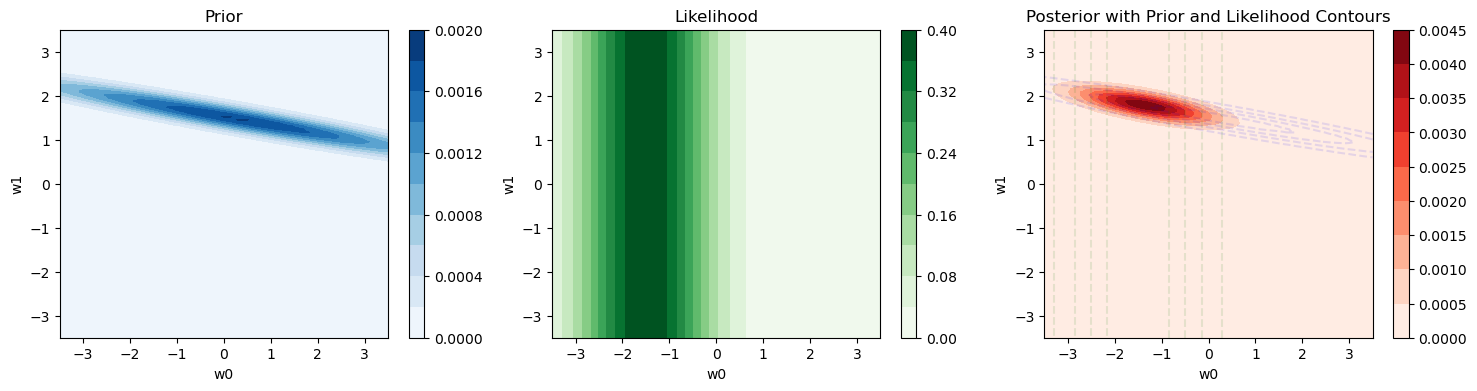

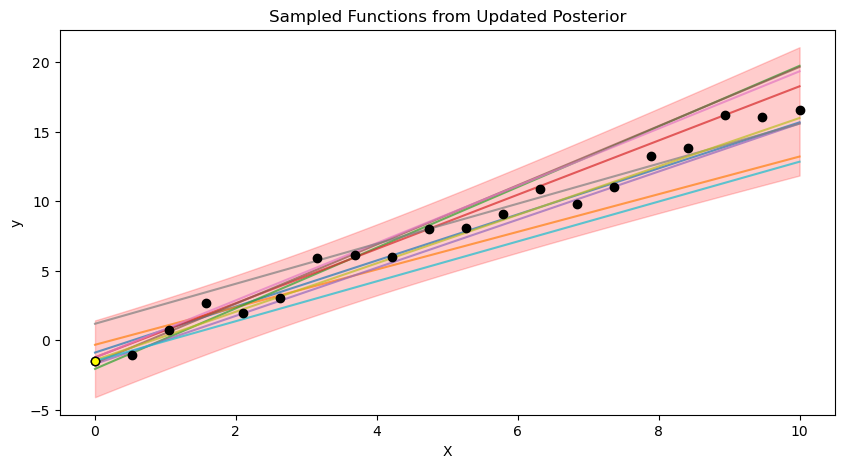

In [24]:
### Hacemos lo mismo de arriba para otro punto.
### Ahora la prioir es una recta (ya no tenemos ni idea de los datos).

# Select a second data point
j =  0 # New data point index
x_j = X_design[j, :]  # Design matrix row for the new point
y_j = y[j]  # Corresponding output value

# Compute the new likelihood for the selected point
likelihood_new = compute_likelihood(w_grid, x_j, y_j, sigma2=sigma2)

# Compute the new posterior (proportional to current posterior * new likelihood)
posterior_updated = posterior * likelihood_new
posterior_updated /= np.sum(posterior_updated)  # Normalize for visualization

# Update the posterior covariance for the new point
Sigma_N_new = np.linalg.inv(
    np.linalg.inv(Sigma_N) + (1 / sigma2) * np.outer(x_j, x_j)
)

# Update the posterior mean for the new point
w_N_new = Sigma_N_new @ (
    np.linalg.inv(Sigma_N) @ w_N + (1 / sigma2) * x_j * y_j
)

plot_updates(prior=posterior, likelihood=likelihood_new, posterior=posterior_updated, point_selected=j, 
            n_samples = 10, means = w_N_new, covs = Sigma_N_new,)

#Las que pasan por e punto amarillo, estaran en la zona mas verde del likelihood

### Posterior Predictive Distribution

To make predictions at new inputs $ X_* $, we integrate over the posterior:
$$
p(y_* \mid X_*, X, y) = \int p(y_* \mid X_*, w) p(w \mid X, y) \, dw.
$$

Assuming $ y_* \mid X_*, w \sim \mathcal{N}(X_* w, \sigma^2) $, and since $ w \mid X, y \sim \mathcal{N}(w_N, \Sigma_N) $, the predictive distribution is Gaussian:
$$
p(y_* \mid X_*, X, y) = \mathcal{N}(X_* w_N, X_* \Sigma_N X_*^T + \sigma^2).
$$

**Mean:**
$$
\mathbb{E}[y_*] = X_* w_N.
$$

**Variance:**
$$
\text{Var}(y_*) = X_* \Sigma_N X_*^T + \sigma^2.
$$


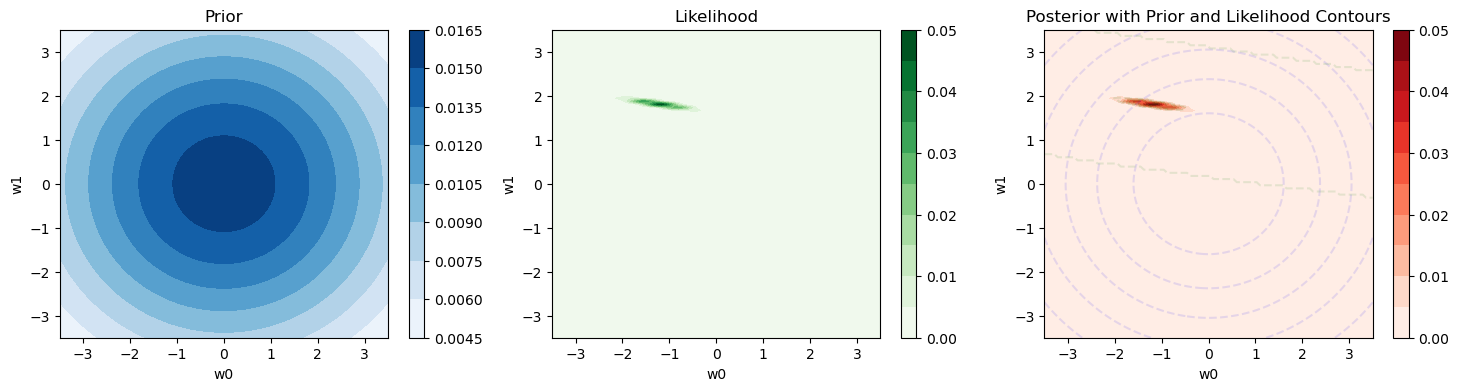

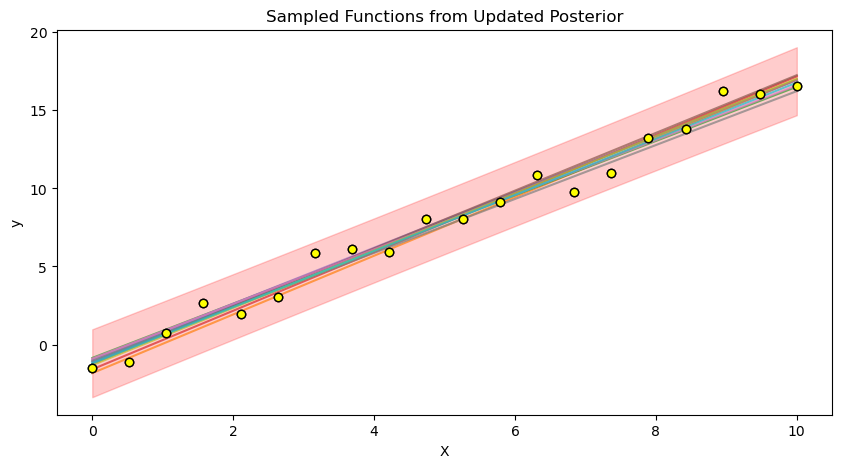

In [26]:
# Use the full dataset for the update
Sigma_N_full = np.linalg.inv(
    np.linalg.inv(Sigma0_prior) + (1 / sigma2) * X_design.T @ X_design
)

w_N_full = Sigma_N_full @ (
    np.linalg.inv(Sigma0_prior) @ w0_prior + (1 / sigma2) * X_design.T @ y
)

# Compute the likelihood for all data points (optional visualization step)
likelihood_all = np.ones_like(w0_grid)  # Placeholder for combined likelihood
for i in range(len(y)):
    x_i = X_design[i, :]
    y_i = y[i]
    likelihood_i = compute_likelihood(w_grid, x_i, y_i, sigma2=sigma2)
    likelihood_all *= likelihood_i
likelihood_all /= np.sum(likelihood_all)  # Normalize for visualization

# Compute the posterior (proportional to prior * combined likelihood)
posterior_full = prior * likelihood_all
posterior_full /= np.sum(posterior_full)  # Normalize for visualization


# Plot updates
plot_updates(
    prior=prior,
    likelihood=likelihood_all,
    posterior=posterior_full,
    point_selected=None,  # No single point since this uses the full dataset
    n_samples=10,
    means=w_N_full,
    covs=Sigma_N_full,
)

#### Lo sombreado en la zona donde deberian estar las betas en funcion de los datos.


import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# Set random seed for reproducibility
np.random.seed(42)

# True parameters for synthetic data generation
true_w = np.array([-2.0, 2.0])  # [w0 (bias), w1 (slope)]
true_sigma = 1  # Noise standard deviation

# Generate synthetic data
X = np.linspace(0, 10, 20)  # Input values
y = true_w[0] + true_w[1] * X + np.random.normal(0, true_sigma, size=X.shape)  # Observations

# Add a bias column to X
X_design = np.vstack([np.ones_like(X), X]).T  # Design matrix with bias

# %% [markdown]
# ## Data Visualization
#
# Let's start by visualizing the generated data to understand the problem we are modeling.

# %%
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color="blue", label="Observations")
plt.title("Synthetic Data for Bayesian Linear Regression")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

# %% [markdown]
# ## Prior Distribution
#
# We place a Gaussian prior on the weights:
# $$
# w \sim \mathcal{N}(w_0, \Sigma_0),
# $$
# where:
# - $ w_0 $ is the prior mean,
# - $ \Sigma_0 $ is the prior covariance.
#
# For simplicity, we assume:
# - $ w_0 = [0, 0]^T $ (zero prior mean),
# - $ \Sigma_0 = \text{diag}([10, 10]) $ (large prior variance).

# %%
# Prior parameters
w0_prior = np.array([0, 0])  # Prior mean
Sigma0_prior = np.diag([10, 10])  # Prior covariance matrix

# %% [markdown]
# ### Sampling from the Prior
#
# Let's visualize some functions sampled from the prior distribution to understand the variability allowed by the prior.

# %%
n_samples_prior = 10
w_samples = multivariate_normal.rvs(w0_prior, Sigma0_prior, size=n_samples_prior)

plt.figure(figsize=(8, 5))
for sample in range(n_samples_prior):
    y_sampled = w_samples[sample, 0] + w_samples[sample, 1] * X
    plt.plot(X, y_sampled, alpha=0.7, label=f"Sample {sample+1}" if sample < 5 else None)

plt.scatter(X, y, color="black", label="Observed Data", zorder=5)
plt.title("Samples from the Prior")
plt.xlabel("X")
plt.ylabel("y")
plt.grid(True)
plt.legend()
plt.show()

# %% [markdown]
# ## Likelihood
#
# The likelihood of the data is:
# $$
# p(y | X, w) = \mathcal{N}(y | Xw, \sigma^2 I),
# $$
# where:
# - $ \sigma^2 $ is the variance of the Gaussian noise.
#
# ### Point-wise Updates
#
# Bayesian updating allows us to compute the posterior incrementally by updating the prior with the likelihood of each new data point.

# %%
def compute_likelihood(w_grid, x_i, y_i, sigma2):
    """Compute the likelihood for a grid of weights given one data point."""
    likelihood = np.zeros(w_grid.shape[:2])
    for i in range(w_grid.shape[0]):
        for j in range(w_grid.shape[1]):
            w = w_grid[i, j, :]
            y_pred = x_i @ w
            likelihood[i, j] = np.exp(-0.5 * (y_i - y_pred)**2 / sigma2) / np.sqrt(2 * np.pi * sigma2)
    return likelihood

# Define the weight grid
w0_range = np.linspace(-3.5, 3.5, 100)
w1_range = np.linspace(-3.5, 3.5, 100)
w0_grid, w1_grid = np.meshgrid(w0_range, w1_range)
w_grid = np.dstack((w0_grid, w1_grid))

# Compute the prior
prior = multivariate_normal.pdf(w_grid, mean=w0_prior, cov=Sigma0_prior)

# %% [markdown]
# ### Visualization of Updates
#
# We now visualize the step-by-step Bayesian updates to the posterior using one data point at a time.

# %%
def plot_updates(prior, likelihood, posterior, point_selected, w0_grid=w0_grid, w1_grid=w1_grid, 
                 means=None, covs=None, n_samples=10):
    """Visualize updates for prior, likelihood, and posterior."""
    plt.figure(figsize=(18, 5))

    # Plot prior
    plt.subplot(1, 3, 1)
    plt.contourf(w0_grid, w1_grid, prior, levels=10, cmap="Blues")
    plt.colorbar()
    plt.title("Prior Distribution")
    plt.xlabel("w0")
    plt.ylabel("w1")

    # Plot likelihood
    plt.subplot(1, 3, 2)
    plt.contourf(w0_grid, w1_grid, likelihood, levels=10, cmap="Greens")
    plt.colorbar()
    plt.title("Likelihood")
    plt.xlabel("w0")
    plt.ylabel("w1")

    # Plot posterior
    plt.subplot(1, 3, 3)
    plt.contourf(w0_grid, w1_grid, posterior, levels=10, cmap="Reds")
    plt.colorbar()
    plt.title("Posterior Distribution")
    plt.xlabel("w0")
    plt.ylabel("w1")

    # Visualize sampled functions
    if means is not None and covs is not None:
        w_posterior_samples = multivariate_normal.rvs(mean=means, cov=covs, size=n_samples)
        X_line = np.linspace(X.min(), X.max(), 100)
        X_line_design = np.vstack([np.ones_like(X_line), X_line]).T
        plt.figure(figsize=(8, 5))
        for w_sample in w_posterior_samples:
            y_sample = X_line_design @ w_sample
            plt.plot(X_line, y_sample, alpha=0.7)
        plt.scatter(X, y, color="black", label="Observed Data")
        plt.title("Functions Sampled from Posterior")
        plt.xlabel("X")
        plt.ylabel("y")
        plt.grid(True)
        plt.legend()
        plt.show()

# Select one data point
i = 10
x_i = X_design[i, :]
y_i = y[i]

# Compute likelihood and posterior for one data point
sigma2 = true_sigma**2
likelihood = compute_likelihood(w_grid, x_i, y_i, sigma2)
posterior = prior * likelihood
posterior /= np.sum(posterior)

# Update mean and covariance
Sigma_N = np.linalg.inv(np.linalg.inv(Sigma0_prior) + (1 / sigma2) * np.outer(x_i, x_i))
w_N = Sigma_N @ (np.linalg.inv(Sigma0_prior) @ w0_prior + (1 / sigma2) * x_i * y_i)

plot_updates(prior, likelihood, posterior, point_selected=i, means=w_N, covs=Sigma_N)

# %% [markdown]
# ## Posterior Predictive Distribution
#
# The predictive distribution at a new input $ X_* $ is:
# $$
# p(y_* | X_*, X, y) = \mathcal{N}(y_* | X_* w_N, X_* \Sigma_N X_*^T + \sigma^2).
# $$

# %%
# Predictive mean and variance
X_new = np.linspace(0, 10, 100)
X_new_design = np.vstack([np.ones_like(X_new), X_new]).T
predictive_mean = X_new_design @ w_N
predictive_variance = np.sum(X_new_design @ Sigma_N * X_new_design, axis=1) + sigma2
predictive_std = np.sqrt(predictive_variance)

plt.figure(figsize=(8, 5))
plt.scatter(X, y, color="black", label="Observed Data")
plt.plot(X_new, predictive_mean, color="red", label="Predictive Mean")
plt.fill_between(
    X_new,
    predictive_mean - 2 * predictive_std,
    predictive_mean + 2 * predictive_std,
    color="red",
    alpha=0.2,
    label="95% Predictive Interval"
)
plt.title("Posterior Predictive Distribution")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()


# Non-Linear regression

## A recap on Multidimensional Normal Distribution

The **Multivariate Normal Distribution** is a generalization of the one-dimensional normal distribution to multiple variables. It is characterized by:

1. A **mean vector** $ \mu $, which contains the means of each variable.
2. A **covariance matrix** $ \Sigma $, which encodes the variance of each variable along the diagonal and the covariances (relationships) between variables off-diagonal.

The probability density function (PDF) for a multivariate normal distribution is given by:

$$
p(\mathbf{x}) = \frac{1}{(2\pi)^{d/2} |\Sigma|^{1/2}} \exp \left( -\frac{1}{2} (\mathbf{x} - \mu)^T \Sigma^{-1} (\mathbf{x} - \mu) \right),
$$

where:

- $ \mathbf{x} $ is a $ d $-dimensional vector,
- $ \mu $ is the mean vector ($ d $-dimensional),
- $ \Sigma $ is the covariance matrix ($ d \times d $).

## Key Properties:

1. **Marginal Distributions**: For a subset of dimensions, the marginal distribution is also normal.
2. **Conditional Distributions**: The distribution of one variable given another is also normal.
3. **Covariance Matrix**: Controls the shape and orientation of the distribution:
   - **Large variances**: More spread in the corresponding variable.
   - **Positive covariance**: Variables move together.
   - **Negative covariance**: Variables move in opposite directions.


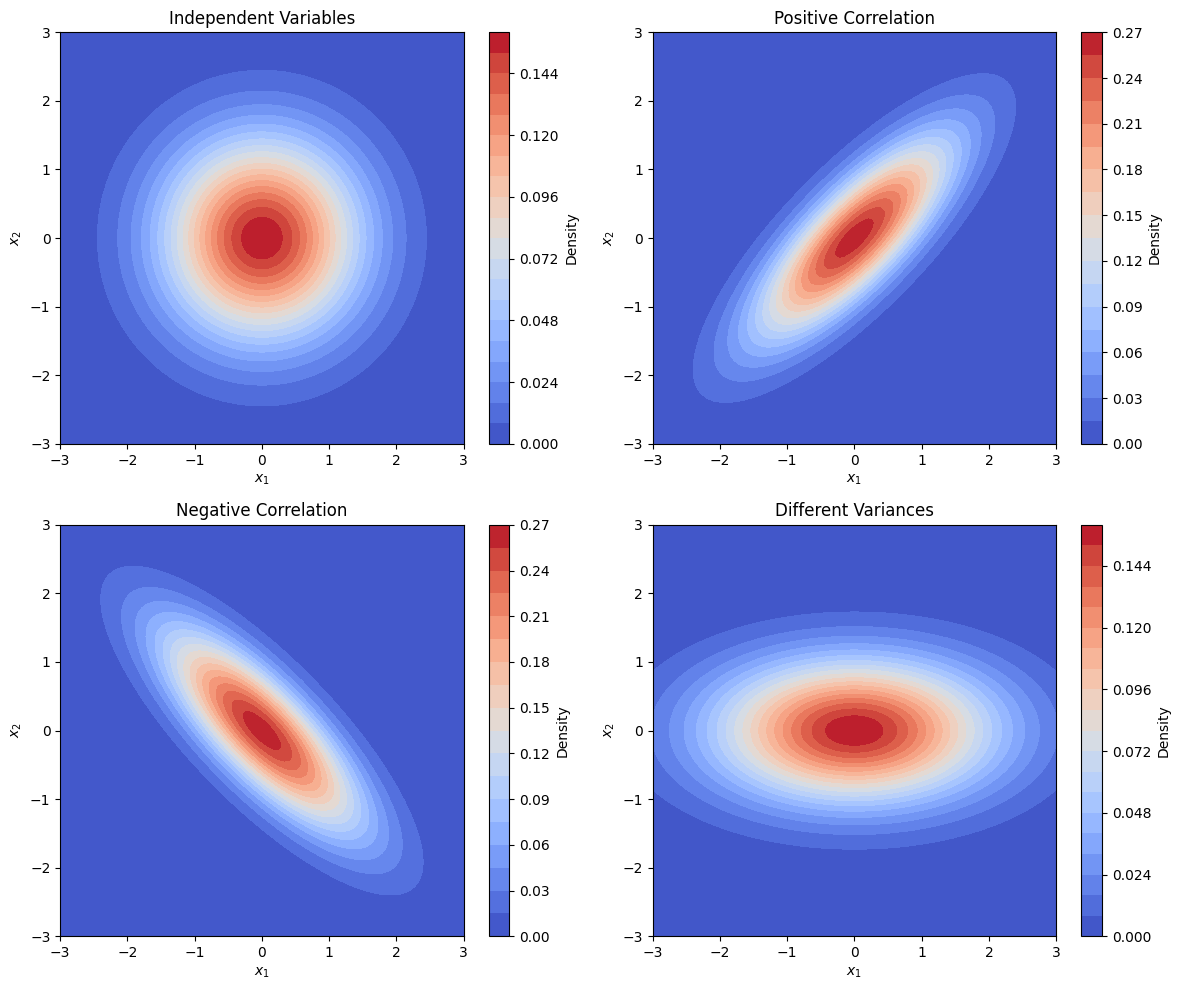

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# Create a grid of (x1, x2) points
x1, x2 = np.meshgrid(np.linspace(-3, 3, 100), np.linspace(-3, 3, 100))
pos = np.dstack((x1, x2))

# Define covariance matrices for different cases
covariances = [
    {"name": "Independent Variables", "cov": [[1, 0], [0, 1]]},
    {"name": "Positive Correlation", "cov": [[1, 0.8], [0.8, 1]]},
    {"name": "Negative Correlation", "cov": [[1, -0.8], [-0.8, 1]]},
    {"name": "Different Variances", "cov": [[2, 0], [0, 0.5]]},
]

# Visualize each case
plt.figure(figsize=(12, 10))
for i, cov_data in enumerate(covariances, start=1):
    # Compute PDF for the current covariance matrix
    cov = cov_data["cov"]
    mean = [0, 0]
    rv = multivariate_normal(mean, cov)
    pdf = rv.pdf(pos)

    # Plot the 2D PDF
    plt.subplot(2, 2, i)
    plt.contourf(x1, x2, pdf, levels=20, cmap="coolwarm")
    plt.title(cov_data["name"])
    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$")
    plt.colorbar(label="Density")

plt.tight_layout()
plt.show()
### Conocido el valor de una variable, obtenemos una normal para la otra variable.

## Joint and Conditional Distributions

In a multivariate normal distribution:

1. The **joint distribution** of all variables is still multivariate normal.
2. The **conditional distribution** of one variable given another is a univariate normal distribution.

For example, in a 2D Normal distribution $ \mathbf{X} \sim \mathcal{N}(\mu, \Sigma) $:

- Let $ \mathbf{X} = [X_1, X_2] $.
- The conditional distribution of $X_2 \mid X_1 $ is:

$$
X_2 \mid X_1 = x_1 \sim \mathcal{N}(\mu_2 + \Sigma_{21} \Sigma_{11}^{-1}(x_1 - \mu_1), \Sigma_{22} - \Sigma_{21} \Sigma_{11}^{-1} \Sigma_{12}),
$$

where:

- $ \mu_1, \mu_2 $ are the means,
- $ \Sigma_{11}, \Sigma_{22} $ are the variances,
- $ \Sigma_{12}, \Sigma_{21} $ are the covariances.


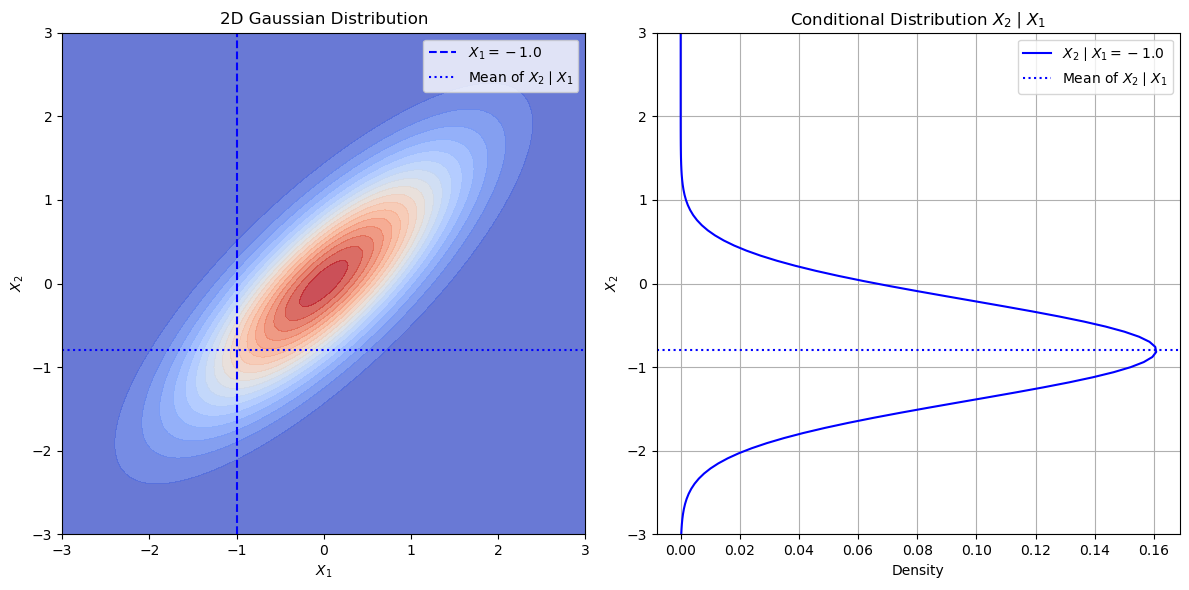

In [32]:
# Define the mean and covariance
mu = np.array([0, 0])  # Mean vector
Sigma = np.array([[1, 0.8], [0.8, 1]])  # Covariance matrix

# Select a fixed value for X1
x1_fixed = -1.0

# Compute conditional mean and variance
mu_2_given_1 = mu[1] + Sigma[1, 0] / Sigma[0, 0] * (x1_fixed - mu[0])
sigma2_2_given_1 = Sigma[1, 1] - (Sigma[1, 0] ** 2) / Sigma[0, 0]

# Create grid for the 2D distribution
x1, x2 = np.meshgrid(np.linspace(-3, 3, 100), np.linspace(-3, 3, 100))
pos = np.dstack((x1, x2))

# Compute the 2D Gaussian PDF
rv = multivariate_normal(mean=mu, cov=Sigma)
pdf_2d = rv.pdf(pos)

# Compute the conditional distribution of X2 | X1
x2_range = np.linspace(-3, 3, 100)
conditional_pdf = multivariate_normal.pdf(
    np.column_stack([x1_fixed * np.ones_like(x2_range), x2_range]), mean=mu, cov=Sigma
)

# Plotting
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Left: 2D Gaussian with vertical line for X1 = x1_fixed
ax[0].contourf(x1, x2, pdf_2d, levels=20, cmap="coolwarm", alpha=0.8)
ax[0].axvline(x=x1_fixed, color="blue", linestyle="--", label=f"$X_1 = {x1_fixed}$")
ax[0].set_title("2D Gaussian Distribution")
ax[0].axhline(mu_2_given_1, color="blue", linestyle="dotted", label=f"Mean of $X_2 \\mid X_1$")
ax[0].set_xlabel("$X_1$")
ax[0].set_ylabel("$X_2$")
ax[0].legend()

# Right: Conditional distribution of X2 given X1
ax[1].plot(conditional_pdf, x2_range, color="blue", label=f"$X_2 \\mid X_1 = {x1_fixed}$")
ax[1].axhline(mu_2_given_1, color="blue", linestyle="dotted", label=f"Mean of $X_2 \\mid X_1$")
ax[1].set_title("Conditional Distribution $X_2 \\mid X_1$")
ax[1].set_ylabel("$X_2$")
ax[1].set_ylim(-3, 3) 
ax[1].set_xlabel("Density")
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

## Si x_2 es -1, entonce

Now, we can see that the value of X2 is a linear function of X1, with a slope given by the covariance between X1 and X2, and an intercept given by the mean of X2 plus the covariance between X2 and X1 times the inverse of the variance of X1.

Let's express the value of X1 and X2 as two different time points, and see how the value of X2 at time t+1 is a linear function of the value of X1 at time t.

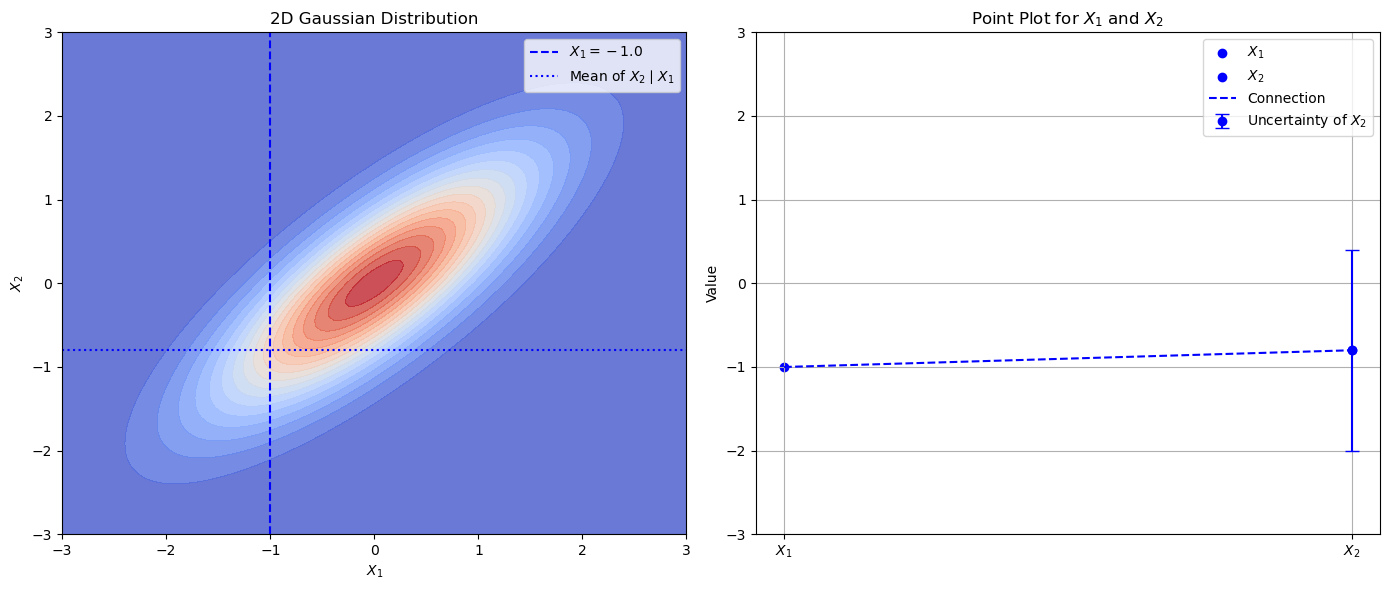

In [34]:
# Define the mean and covariance
mu = np.array([0, 0])  # Mean vector
Sigma = np.array([[1, 0.8], [0.8, 1]])  # Covariance matrix

# Select a fixed value for X1
x1_fixed = -1.0

# Compute conditional mean and variance
mu_2_given_1 = mu[1] + Sigma[1, 0] / Sigma[0, 0] * (x1_fixed - mu[0])
sigma2_2_given_1 = Sigma[1, 1] - (Sigma[1, 0] ** 2) / Sigma[0, 0]

# Create grid for the 2D distribution
x1, x2 = np.meshgrid(np.linspace(-3, 3, 100), np.linspace(-3, 3, 100))
pos = np.dstack((x1, x2))

# Compute the 2D Gaussian PDF
rv = multivariate_normal(mean=mu, cov=Sigma)
pdf_2d = rv.pdf(pos)

# Compute the conditional distribution of X2 | X1
x2_range = np.linspace(-3, 3, 100)
conditional_pdf = multivariate_normal.pdf(
    np.column_stack([x1_fixed * np.ones_like(x2_range), x2_range]), mean=mu, cov=Sigma
)

# Plotting
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Left: 2D Gaussian with vertical line for X1 = x1_fixed
ax[0].contourf(x1, x2, pdf_2d, levels=20, cmap="coolwarm", alpha=0.8)
ax[0].axvline(x=x1_fixed, color="blue", linestyle="--", label=f"$X_1 = {x1_fixed}$")
ax[0].axhline(mu_2_given_1, color="blue", linestyle="dotted", label=f"Mean of $X_2 \\mid X_1$")
ax[0].set_title("2D Gaussian Distribution")
ax[0].set_xlabel("$X_1$")
ax[0].set_ylabel("$X_2$")
ax[0].legend()

# Right: Point plot for X1 and X2 with uncertainty
ax[1].scatter([1], [x1_fixed], color="blue", label="$X_1$")
ax[1].scatter([2], [mu_2_given_1], color="blue", label="$X_2$")
ax[1].errorbar(
    [2], [mu_2_given_1], 
    yerr=2 * np.sqrt(sigma2_2_given_1), 
    fmt="o", color="blue", capsize=5, label="Uncertainty of $X_2$"
)
ax[1].plot([1, 2], [x1_fixed, mu_2_given_1], linestyle="--", color="blue", label="Connection")
ax[1].set_title("Point Plot for $X_1$ and $X_2$")
ax[1].set_xticks([1, 2])
ax[1].set_xticklabels(["$X_1$", "$X_2$"])
ax[1].set_ylabel("Value")
ax[1].set_ylim(-3, 3) 
ax[1].grid(True)
ax[1].legend()

plt.tight_layout()
plt.show()

#### Cambiamos la interpretación a la evolución de una serie temporal. Vamos a pensarlo como un valor de una serie temporal.
##### x_1 = x(t=1)
##### Lo de abajo tiene una serie temporal

We have already seen that, based on a common distribution between dimensions, we can express the conditional distribution of one variable given another as a function of the other variable. But what would happen if we increase the number of dimensions of the gaussian distribution?

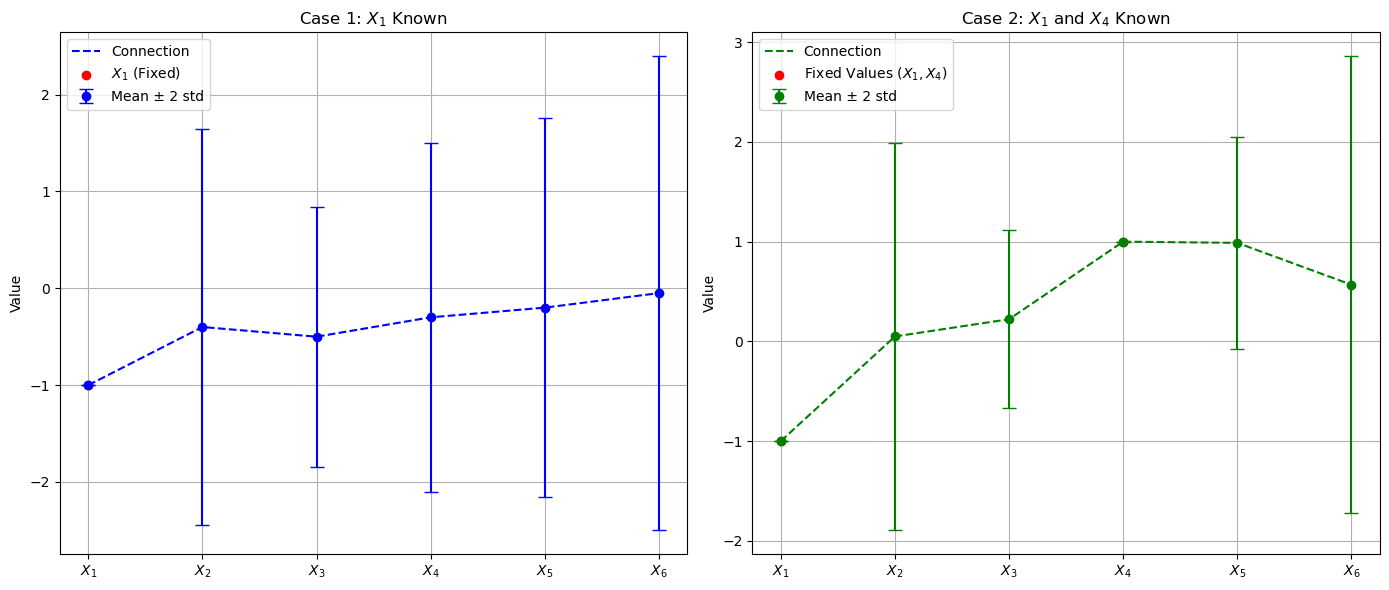

In [13]:
# Define the mean and covariance
n_dimensions = 6  # Number of dimensions
mu = np.zeros(n_dimensions)  # Mean vector
sigma_xx = [1.0, 1.2, 0.7, 0.9, 1.0, 1.5]
sigma_xy = {'x1': [0.4, 0.5, 0.3, 0.2, 0.05], 
            'x2': [0.6, 0.4, 0.2, 0.1],
            'x3': [0.6, 0.3, 0.2],
            'x4': [0.8, 0.4],
            'x5': [0.9],}



###### Matriz de covarianzas (es simetrica)

Sigma = np.array([
    [sigma_xx[0],       sigma_xy['x1'][0], sigma_xy['x1'][1], sigma_xy['x1'][2], sigma_xy['x1'][3], sigma_xy['x1'][4]],
    [sigma_xy['x1'][0], sigma_xx[1],       sigma_xy['x2'][0], sigma_xy['x2'][1], sigma_xy['x2'][2], sigma_xy['x2'][3]],
    [sigma_xy['x1'][1], sigma_xy['x2'][0], sigma_xx[2],       sigma_xy['x3'][0], sigma_xy['x3'][1], sigma_xy['x3'][2]],
    [sigma_xy['x1'][2], sigma_xy['x2'][1], sigma_xy['x3'][0], sigma_xx[3],       sigma_xy['x4'][0], sigma_xy['x4'][1]],
    [sigma_xy['x1'][3], sigma_xy['x2'][2], sigma_xy['x3'][1], sigma_xy['x4'][0], sigma_xx[4],       sigma_xy['x5'][0]],
    [sigma_xy['x1'][4], sigma_xy['x2'][3], sigma_xy['x3'][2], sigma_xy['x4'][1], sigma_xy['x5'][0], sigma_xx[5]]
])  # Full covariance matrix

variables = np.arange(n_dimensions)  # Indices from 0 to 5

# Case 1: Fix X1
x1_fixed = -1.0
K = [0]  # Indices of known variables
U = [i for i in variables if i not in K]  # Indices of unknown variables

x_K = np.array([x1_fixed])
mu_K = mu[K]
mu_U = mu[U]

Sigma_KK = Sigma[np.ix_(K, K)]
Sigma_UK = Sigma[np.ix_(U, K)]
Sigma_UU = Sigma[np.ix_(U, U)]

Sigma_KK_inv = np.linalg.inv(Sigma_KK)

mu_cond = mu_U + Sigma_UK @ Sigma_KK_inv @ (x_K - mu_K)
Sigma_cond = Sigma_UU - Sigma_UK @ Sigma_KK_inv @ Sigma_UK.T

# Prepare arrays for plotting
values_case_1 = np.zeros(n_dimensions)
uncertainties_case_1 = np.zeros(n_dimensions)

for idx in variables:
    if idx in K:
        values_case_1[idx] = x_K[K.index(idx)]
        uncertainties_case_1[idx] = 0
    else:
        u_idx = U.index(idx)
        values_case_1[idx] = mu_cond[u_idx]
        uncertainties_case_1[idx] = 2 * np.sqrt(Sigma_cond[u_idx, u_idx])

# Case 2: Fix X1 and X4
x4_fixed = 1.0
K = [0, 3]  # Indices of known variables
U = [i for i in variables if i not in K]  # Indices of unknown variables

x_K = np.array([x1_fixed, x4_fixed])
mu_K = mu[K]
mu_U = mu[U]

Sigma_KK = Sigma[np.ix_(K, K)]
Sigma_UK = Sigma[np.ix_(U, K)]
Sigma_UU = Sigma[np.ix_(U, U)]

Sigma_KK_inv = np.linalg.inv(Sigma_KK)

mu_cond = mu_U + Sigma_UK @ Sigma_KK_inv @ (x_K - mu_K)
Sigma_cond = Sigma_UU - Sigma_UK @ Sigma_KK_inv @ Sigma_UK.T

# Prepare arrays for plotting
values_case_2 = np.zeros(n_dimensions)
uncertainties_case_2 = np.zeros(n_dimensions)

for idx in variables:
    if idx in K:
        values_case_2[idx] = x_K[K.index(idx)]
        uncertainties_case_2[idx] = 0
    else:
        u_idx = U.index(idx)
        values_case_2[idx] = mu_cond[u_idx]
        uncertainties_case_2[idx] = 2 * np.sqrt(Sigma_cond[u_idx, u_idx])

# Plotting
dimensions = np.arange(1, n_dimensions + 1)

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Plotting Case 1
ax[0].errorbar(dimensions, values_case_1, yerr=uncertainties_case_1, fmt="o", capsize=5, color="blue", label="Mean ± 2 std")
ax[0].plot(dimensions, values_case_1, linestyle="--", color="blue", label="Connection")
ax[0].scatter(1, x1_fixed, color="red", label="$X_1$ (Fixed)")
ax[0].set_title("Case 1: $X_1$ Known")
ax[0].set_xticks(dimensions)
ax[0].set_xticklabels([f"$X_{i}$" for i in dimensions])
ax[0].set_ylabel("Value")
ax[0].grid(True)
ax[0].legend()

# Plotting Case 2
ax[1].errorbar(dimensions, values_case_2, yerr=uncertainties_case_2, fmt="o", capsize=5, color="green", label="Mean ± 2 std")
ax[1].plot(dimensions, values_case_2, linestyle="--", color="green", label="Connection")
ax[1].scatter([1, 4], [x1_fixed, x4_fixed], color="red", label="Fixed Values ($X_1, X_4$)")
ax[1].set_title("Case 2: $X_1$ and $X_4$ Known")
ax[1].set_xticks(dimensions)
ax[1].set_xticklabels([f"$X_{i}$" for i in dimensions])
ax[1].set_ylabel("Value")
ax[1].grid(True)
ax[1].legend()

plt.tight_layout()
plt.show()


#### Es lo mismo que antes pero en mas dimensiones.


##### En el segundo caso, conocemos x_1 y x_4. Vemos como se ha reducido la invertidumbre de x_4 (porque tengo informacion local cercana a x_3)

#### La covarianza es la que va a determinar la incertidumbre que vemos en cada variable.

Once we have the uncertainty around each dimension, we can sample from each distribution (i.e., then normals) and create realizations from the stochastic process. This is the essence of Gaussian Processes.

/var/folders/6r/17dbwpxj45s03vzxrc5kddj40000gn/T/ipykernel_61249/858536559.py:5: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  samples_U = np.random.multivariate_normal(mu_cond, Sigma_cond, size=n_realizations)


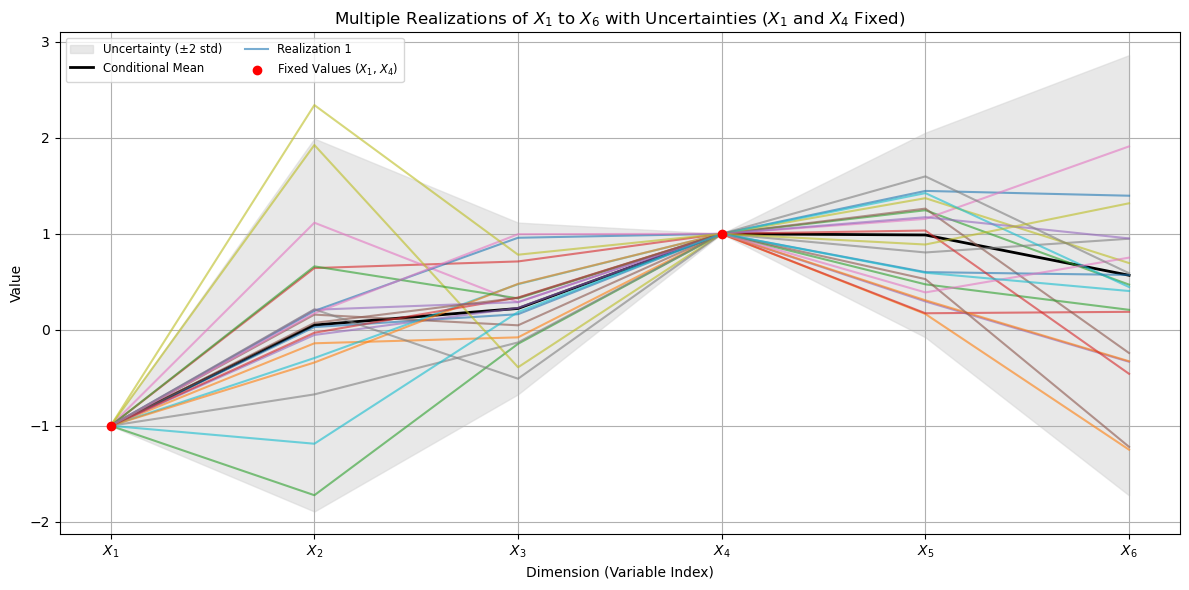

In [16]:
# Number of samples (realizations) to generate
n_realizations = 20

# Generate samples from the conditional distribution
samples_U = np.random.multivariate_normal(mu_cond, Sigma_cond, size=n_realizations)

# Build full samples including fixed values
samples_full = np.zeros((n_realizations, n_dimensions))
for i in range(n_realizations):
    sample = np.zeros(n_dimensions)
    for idx in variables:
        if idx in K:
            # Insert fixed values
            sample[idx] = x_K[K.index(idx)]
        else:
            # Insert sampled values
            u_idx = U.index(idx)
            sample[idx] = samples_U[i, u_idx]
    samples_full[i] = sample

# Compute uncertainties (standard deviations)
std_devs = np.zeros(n_dimensions)
for idx in variables:
    if idx in K:
        std_devs[idx] = 0  # Known variables have zero uncertainty
    else:
        u_idx = U.index(idx)
        std_devs[idx] = np.sqrt(Sigma_cond[u_idx, u_idx])

# Prepare the conditional mean values for plotting
values_case_2 = np.zeros(n_dimensions)
for idx in variables:
    if idx in K:
        values_case_2[idx] = x_K[K.index(idx)]
    else:
        u_idx = U.index(idx)
        values_case_2[idx] = mu_cond[u_idx]

# Calculate upper and lower bounds for uncertainties (±2 standard deviations)
upper_bound = values_case_2 + 2 * std_devs
lower_bound = values_case_2 - 2 * std_devs

# Now, plot the samples as time series along with uncertainties
dimensions = np.arange(1, n_dimensions + 1)  # For plotting (X1 to X6)

plt.figure(figsize=(12, 6))

# Plot the uncertainties as a shaded area
plt.fill_between(dimensions, lower_bound, upper_bound, color='lightgrey', alpha=0.5, label='Uncertainty (±2 std)')

# Plot the conditional mean
plt.plot(dimensions, values_case_2, color='black', linewidth=2, label='Conditional Mean')

# Plot each realization
for i in range(n_realizations):
    plt.plot(dimensions, samples_full[i], alpha=0.6, label=f'Realization {i+1}' if i < 1 else '')  # Label only the first realization

# Highlight the fixed values
plt.scatter([1, 4], [x1_fixed, x4_fixed], color='red', zorder=5, label='Fixed Values ($X_1$, $X_4$)')

# Customize the plot
plt.title('Multiple Realizations of $X_1$ to $X_6$ with Uncertainties ($X_1$ and $X_4$ Fixed)')
plt.xlabel('Dimension (Variable Index)')
plt.ylabel('Value')
plt.xticks(dimensions, [f'$X_{i}$' for i in dimensions])
plt.grid(True)
plt.legend(loc='upper left', ncol=2, fontsize='small')
plt.tight_layout()
plt.show()


### Los puntos rojos son los que conocemos. 


### Datos funcionales: X


El código está simulando cómo se distribuyen las variables desconocidas (X_2, X_3, X_5, X_6) bajo las restricciones impuestas por los valores conocidos (X_1 = x_1, X_4 = x_4). Esto es consistente con las propiedades de las distribuciones normales multivariantes, donde las medias condicionales son lineales y las incertidumbres se calculan a partir de la covarianza condicional.

However, this only serves us if we have a finite number of possible values for X. If we want to model a continuous function, we need to consider the limit of the number of dimensions going to infinity. This is the essence of Gaussian Processes.

# Gaussian Processes (GPs)

Now that we've explored Bayesian linear regression and multivariate normal distributions, we're ready to delve into **Gaussian Processes (GPs)**. GPs extend the concept of multivariate normal distributions to infinite dimensions, allowing us to define a prior over functions. This is a powerful tool for non-linear regression and modeling complex data relationships.



## What is a Gaussian Process?

A **Gaussian Process** is a collection of random variables, any finite number of which have a joint Gaussian distribution. In the context of regression, a GP defines a prior over functions $ f(x) $, which can be updated with data to obtain a posterior over functions.

Mathematically, a GP is specified by a **mean function** $ m(x) $ and a **covariance function** (kernel) $ k(x, x') $:

$$
f(x) \sim GP(m(x), k(x, x')).
$$

- **Mean Function $ m(x) $:**
  - Represents the average value of the function at each point $ x $.
  - It's common to assume $ m(x) = 0 $ unless prior knowledge suggests otherwise.

- **Covariance Function $ k(x, x') $:**
  - Encodes our assumptions about the function's smoothness and how function values at different points co-vary.

For any finite set of input points $ X = [x_1, x_2, \ldots, x_n] $, the function values $ f(X) = [f(x_1), f(x_2), \ldots, f(x_n)] $ follow a multivariate normal distribution:

$$
f(X) \sim \mathcal{N}(m(X), K(X, X)),
$$

!!!!!!  El kernel da información de las zonas cercanas. Enteder bien cual es la idea intuitiva detras del significado del kernel.

where $ K(X, X) $ is the covariance matrix computed using the kernel $ k(x, x') $.

# The Prior in Gaussian Processes

Before observing any data, our beliefs about the function $ f(x) $ are entirely captured by the GP prior. This prior expresses our assumptions about the function's behavior.

The choice of kernel is crucial, as it defines the properties of the functions we expect under the prior. The most common used kernel is the **Squared Exponential (RBF) Kernel**:

$$
k_{SE}(x, x') = \sigma_f^2 \exp\left(-\frac{(x - x')^2}{2\ell^2}\right),
$$

- $ \sigma_f^2 $: Signal variance (controls the vertical variation).
- $ \ell $: Length-scale (controls the horizontal length over which the function varies).

## Sampling from the Prior

To build intuition about GPs, we'll sample functions from the prior. This involves:

1. Defining a set of input points $ X $.
2. Computing the covariance matrix $ K(X, X) $ using a chosen kernel.
3. Sampling from the multivariate normal distribution $ \mathcal{N}(m(X), K(X, X)) $.

Let's proceed to sample from a GP prior using the Squared Exponential kernel.


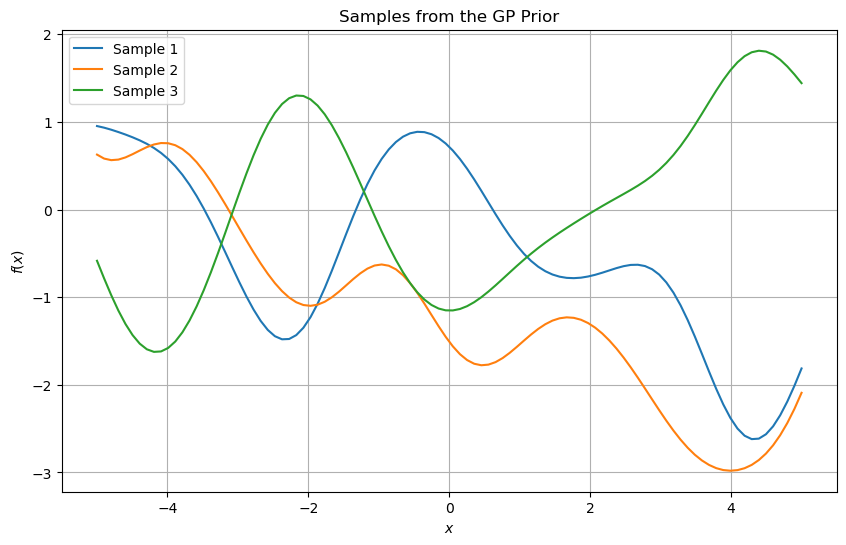

In [21]:
# Define the kernel function (Squared Exponential Kernel)
def squared_exponential_kernel(x1, x2, sigma_f=1.0, ell=1.0):
    """Compute the Squared Exponential (RBF) kernel between x1 and x2."""
    sqdist = np.subtract.outer(x1, x2)**2
    return sigma_f**2 * np.exp(-0.5 * sqdist / ell**2)

# Define input points
X = np.linspace(-5, 5, 100)

# Compute the covariance matrix
sigma_f = 1.0  # Signal variance
ell = 1.0      # Length-scale
K = squared_exponential_kernel(X, X, sigma_f, ell)

# Ensure the covariance matrix is positive definite
K += 1e-8 * np.eye(len(X))

# Sample from the GP prior
n_samples = 3
samples = np.random.multivariate_normal(mean=np.zeros(len(X)), cov=K, size=n_samples)

# Plot the samples
plt.figure(figsize=(10, 6))
for i in range(n_samples):
    plt.plot(X, samples[i], label=f'Sample {i+1}')
plt.title('Samples from the GP Prior')
plt.xlabel('$x$')
plt.ylabel('$f(x)$')
plt.legend()
plt.grid(True)
plt.show()


The plot above shows random functions sampled from the GP prior with a Squared Exponential kernel. These functions are smooth due to the properties of the kernel, which encodes our belief that points close to each other in input space will have similar function values.

- **Smoothness**: The RBF kernel produces infinitely differentiable functions, leading to very smooth samples.
- **Variance**: The functions oscillate around the mean (zero in this case) with a variance controlled by $ \sigma_f^2 $.



# Effect of Hyperparameters

Let's explore how changing the hyperparameters $ \sigma_f $ (signal variance) and $ \ell $ (length-scale) affects the prior samples.


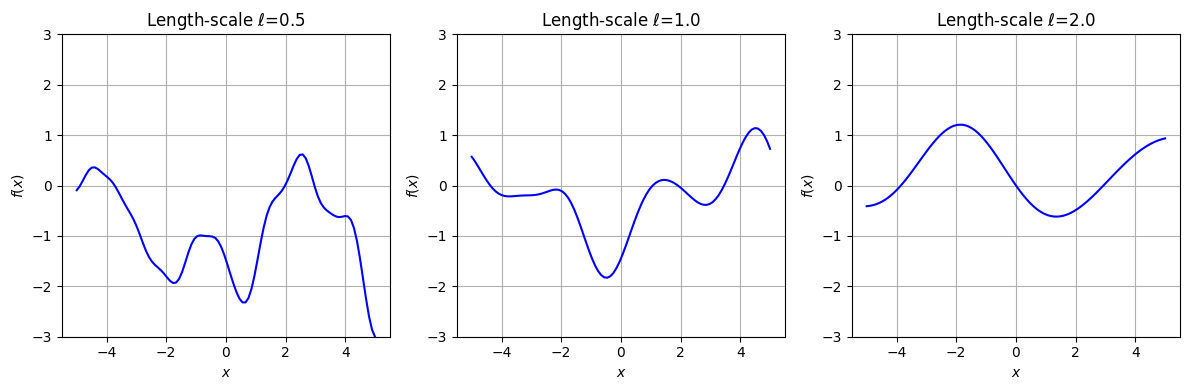

In [62]:
# Define different length-scales and signal variances
length_scales = [0.5, 1.0, 2.0]
signal_variances = [0.5, 1.0, 2.5]

# Plot samples with different length-scales
plt.figure(figsize=(12, 4))

for i, ell in enumerate(length_scales):
    K = squared_exponential_kernel(X, X, sigma_f=1.0, ell=ell)
    K += 1e-8 * np.eye(len(X))
    samples = np.random.multivariate_normal(mean=np.zeros(len(X)), cov=K, size=1)
    plt.subplot(1, 3, i+1)
    plt.plot(X, samples[0], color='blue')
    plt.title(f'Length-scale $\\ell$={ell}')
    plt.xlabel('$x$')
    plt.gca().set_ylim(-3, 3) 
    plt.ylabel('$f(x)$')
    plt.grid(True)

plt.tight_layout()
plt.show()


#### Entnder los gráficos.
### La l cercana a 0 permite mucha variación. l's grandes significa que datos lejanos afectan a mi dato actual.
### l's grandes informaciones

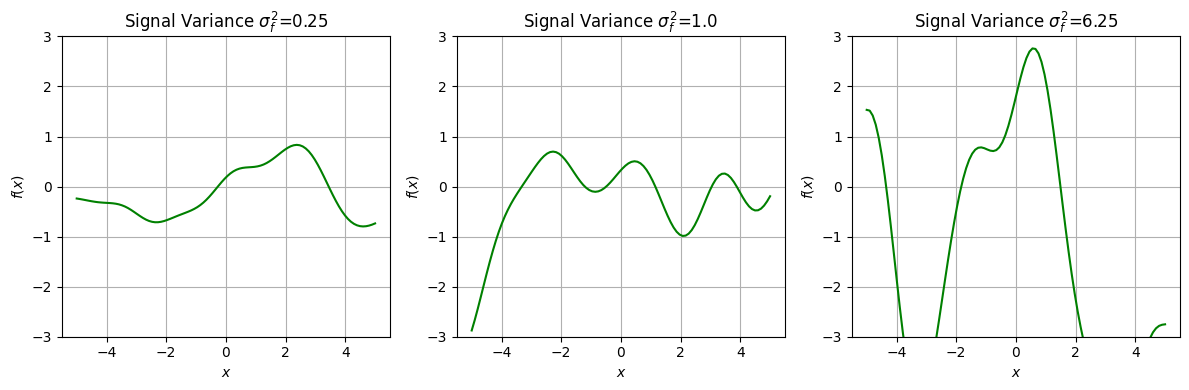

In [64]:
# Plot samples with different signal variances
plt.figure(figsize=(12, 4))

for i, sigma_f in enumerate(signal_variances):
    K = squared_exponential_kernel(X, X, sigma_f=sigma_f, ell=1.0)
    K += 1e-8 * np.eye(len(X))
    samples = np.random.multivariate_normal(mean=np.zeros(len(X)), cov=K, size=1)
    plt.subplot(1, 3, i+1)
    plt.plot(X, samples[0], color='green')
    plt.title(f'Signal Variance $\\sigma_f^2$={sigma_f**2}')
    plt.gca().set_ylim(-3, 3) 
    plt.xlabel('$x$')
    plt.ylabel('$f(x)$')
    plt.grid(True)

plt.tight_layout()
plt.show()

### Entnder los gráficos.

## sigmas grandes permiten, localmente, cambios muy drasticos.

### Length-scale $ \ell $:
- **Small $ \ell $**: Functions vary rapidly, capturing high-frequency variations.
- **Large $ \ell $**: Functions vary slowly, leading to smoother and more globally correlated functions.

### Signal Variance $ \sigma_f^2 $:
- Controls the vertical variation of the functions.
- **Larger $ \sigma_f^2 $** results in functions with greater amplitude variations from the mean.

By adjusting these hyperparameters, we can encode our beliefs about the function's behavior before observing any data.

# Likelihood and Posterior Distribution

In the previous section, we introduced Gaussian Processes (GPs) and how they define a prior over functions through a mean function and a covariance function (kernel). Now, we will incorporate observed data to update our prior beliefs and obtain the posterior distribution over functions.



## Incorporating Data: The Likelihood Function

Given observed data, the likelihood function quantifies how probable the data are under different functions drawn from the prior. In GP regression, we assume that observations are noisy evaluations of the underlying function:

$$
y_i = f(x_i) + \epsilon_i,
$$

where:

- $ y_i $ is the observed output at input $ x_i $,
- $ f(x_i) $ is the true function value at $ x_i $,
- $ \epsilon_i \sim \mathcal{N}(0, \sigma_n^2) $ is Gaussian noise with variance $ \sigma_n^2 $.

The likelihood of the data given the function $ f $ is then:

$$
p(\mathbf{y} \mid f) = \prod_{i=1}^{n} \mathcal{N}(y_i \mid f(x_i), \sigma_n^2).
$$

However, in GP regression, we integrate out $ f $ to obtain the marginal likelihood, which is crucial for hyperparameter tuning.

## Posterior Distribution

Given the prior over functions and the likelihood from the observed data, Bayes' theorem allows us to compute the posterior distribution over functions:

$$
p(f \mid \mathbf{X}, \mathbf{y}) = \frac{p(\mathbf{y} \mid f) p(f)}{p(\mathbf{y} \mid \mathbf{X})}.
$$

In GP regression, due to the properties of Gaussian distributions, we can analytically compute the posterior distribution. Specifically, for any test input points $ \mathbf{X}_* $, the posterior predictive distribution is Gaussian.



## Derivation of the Posterior

Let:

- $ \mathbf{X} $: the observed input points.
- $ \mathbf{y} $: the observed outputs.
- $ \mathbf{X}_* $: the test input points where we want to make predictions.

We define:

- $ \mathbf{f} = f(\mathbf{X}) $ as the function values at observed inputs.
- $ \mathbf{f}_* = f(\mathbf{X}_*) $ as the function values at test inputs.

The joint distribution of $ \mathbf{f} $ and $ \mathbf{f}_* $ under the prior is:
f puntos que conozxo. Datos que no conozco con estrellas.

$$
\begin{bmatrix}
\mathbf{f} \\
\mathbf{f}_*
\end{bmatrix}
\sim \mathcal{N} \left(
\mathbf{0},
\begin{bmatrix}
K(\mathbf{X}, \mathbf{X}) & K(\mathbf{X}, \mathbf{X}_*) \\
K(\mathbf{X}_*, \mathbf{X}) & K(\mathbf{X}_*, \mathbf{X}_*)
\end{bmatrix}
\right),
$$

where $ K(\mathbf{X}, \mathbf{X}) $ is the covariance matrix between observed inputs, and similarly for the other terms.

Because observations include noise, we modify $ K(\mathbf{X}, \mathbf{X}) $ to include the noise variance $ \sigma_n^2 $:

$$
K_{\text{noisy}} = K(\mathbf{X}, \mathbf{X}) + \sigma_n^2 I.
$$



## Computing the Posterior Predictive Distribution !!!!!!!!!

The posterior predictive distribution of $ \mathbf{f}_* $ given $ \mathbf{X} $ and $ \mathbf{y} $ is Gaussian:

$$
\mathbf{f}_* \mid \mathbf{X}, \mathbf{y}, \mathbf{X}_* \sim \mathcal{N}(\mu_*, \Sigma_*),
$$

where: (La media de los puntos que no conozco depende de la salida de los puntos que si conozoco)

- **Mean**:

$$
\mu_* = K(\mathbf{X}_*, \mathbf{X})[K(\mathbf{X}, \mathbf{X}) + \sigma_n^2 I]^{-1} \mathbf{y}.
$$

- **Covariance**: Incertidumbre de la media de los datos que no conozco

$$
\Sigma_* = K(\mathbf{X}_*, \mathbf{X}_*) - K(\mathbf{X}_*, \mathbf{X})[K(\mathbf{X}, \mathbf{X}) + \sigma_n^2 I]^{-1}K(\mathbf{X}, \mathbf{X}_*).
$$

This provides both the predictive mean and the uncertainty at the test inputs $ \mathbf{X}_* $.

### Nomenclature
In order to make the code more readable, we will use the following nomenclature:
#### $ K $

- **Definition**: The covariance matrix of the training data.
- **Formula**:

$$
K = K(\mathbf{X}_{\text{train}}, \mathbf{X}_{\text{train}}) + \sigma_n^2 I
$$

  - $ K(\mathbf{X}_{\text{train}}, \mathbf{X}_{\text{train}}) $: Covariance matrix computed using the kernel function between all pairs of training inputs.
  - $ \sigma_n^2 I $: Noise variance added to the diagonal ($ I $ is the identity matrix).

- **Purpose**: Captures the covariance (similarity) between every pair of training data points, adjusted for observational noise.


#### $ K_s $

- **Definition**: The cross-covariance matrix between the training data and the test data.
- **Formula**:

$$
K_s = K(\mathbf{X}_{\text{train}}, \mathbf{X}_{\text{test}})
$$

  - Computed using the kernel function between each training input and each test input.

- **Purpose**: Represents the covariance between training inputs and test inputs, essential for making predictions at new points.

#### $ K_{ss} $

- **Definition**: The covariance matrix of the test data.
- **Formula**:

$$
K_{ss} = K(\mathbf{X}_{\text{test}}, \mathbf{X}_{\text{test}})
$$

  - Computed using the kernel function between all pairs of test inputs.

- **Purpose**: Captures the covariance among the test data points themselves.


#### $ K_{\text{inv}} $

- **Definition**: The inverse of the covariance matrix $ K $.
- **Formula**:

$$
K_{\text{inv}} = K^{-1}
$$

- **Purpose**: Used in the computation of the posterior predictive mean and covariance. Inverting $ K $ allows us to incorporate the observed data $ \mathbf{y}_{\text{train}} $ into our predictions.

#### $ \mu_s $

- **Definition**: The posterior predictive mean at the test inputs $ \mathbf{X}_{\text{test}} $.
- **Formula**:

$$
\mu_s = K_s^T K_{\text{inv}} \mathbf{y}_{\text{train}}
$$

- **Purpose**: Provides the GP's best estimate of the function values at the test inputs, incorporating information from the observed data.

#### $ \text{cov}_s $

- **Definition**: The posterior predictive covariance matrix at the test inputs $ \mathbf{X}_{\text{test}} $.
- **Formula**:

$$
\text{cov}_s = K_{ss} - K_s^T K_{\text{inv}} K_s
$$

- **Purpose**: Quantifies the uncertainty of the predictions at the test inputs. The diagonal elements give the variance (uncertainty) of each prediction.


Let's implement GP regression using the above equations. 

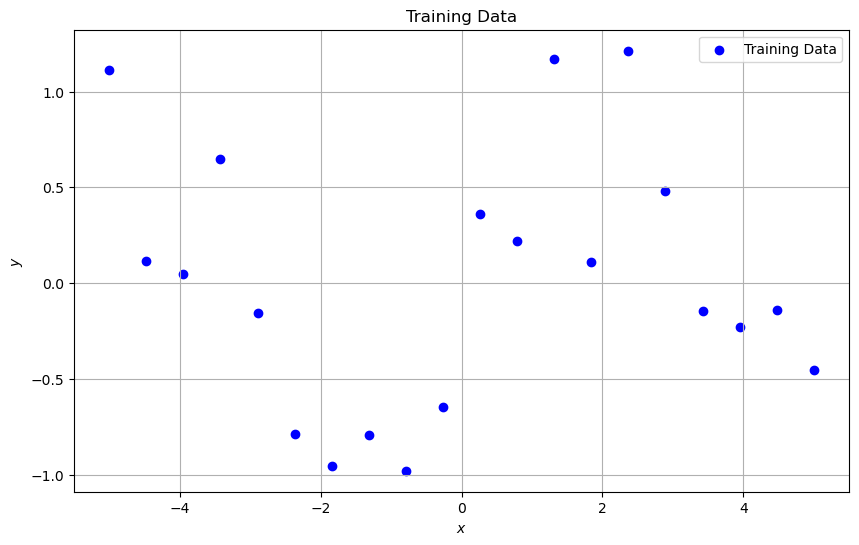

In [48]:
import numpy as np
import matplotlib.pyplot as plt

# Function to model
def f(x):
    return np.sin(x)

# Training data (observed inputs and outputs)
X_train = np.linspace(-5, 5, 20)
### Los puntos de entrenamiento se generan como función de x (en este caso el seno) + un ruido gaussiano 
y_train = f(X_train) + np.random.normal(0, 0.5, size=X_train.shape)

# Plot the training data
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='blue', label='Training Data')
plt.title('Training Data')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.legend()
plt.grid(True)
plt.show()


We'll use the Squared Exponential kernel and implement the GP regression equations.

In [50]:
# Define the kernel function (Squared Exponential Kernel)
def squared_exponential_kernel(x1, x2, sigma_f=1.0, ell=1.0):
    """Compute the Squared Exponential (RBF) kernel between x1 and x2."""
    sqdist = np.subtract.outer(x1, x2)**2
    return sigma_f**2 * np.exp(-0.5 * sqdist / ell**2)

#### ¡¡¡¡¡¡¡¡ Esto es lo que nosotros podemos tocar. Hyperparameters
sigma_f = 1.0   # Signal variance
ell = 1.0       # Length-scale
sigma_n = 0.5   # Noise standard deviation

# Compute covariance matrices
K = squared_exponential_kernel(X_train, X_train, sigma_f, ell)
K += sigma_n**2 * np.eye(len(X_train))  # Add noise variance to the diagonal

# Test inputs
X_test = np.linspace(-7, 7, 100)
K_s = squared_exponential_kernel(X_train, X_test, sigma_f, ell)
K_ss = squared_exponential_kernel(X_test, X_test, sigma_f, ell)
K_inv = np.linalg.inv(K)

# Compute the posterior predictive mean and covariance
##### IMPORTANTES !!!!!!!!!!!!!!!!!
#### (No dependen del tipo de Kernel). Las vamos a tener que utilizar. (Pregunta de test)
mu_s = K_s.T @ K_inv @ y_train
cov_s = K_ss - K_s.T @ K_inv @ K_s

# Compute standard deviations
stdv = np.sqrt(np.diag(cov_s))


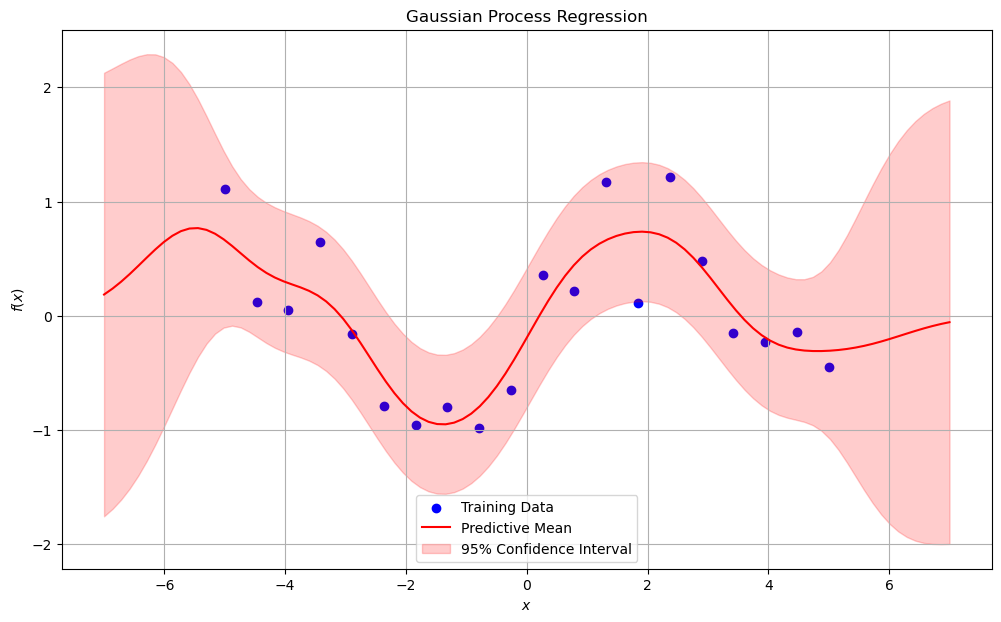

In [52]:
# Plotting
plt.figure(figsize=(12, 7))

# Plot the training data
plt.scatter(X_train, y_train, color='blue', label='Training Data')

# Plot the predictive mean
plt.plot(X_test, mu_s, color='red', label='Predictive Mean')

# Plot the confidence intervals
plt.fill_between(
    X_test,
    mu_s - 1.96 * stdv,
    mu_s + 1.96 * stdv,
    alpha=0.2,
    color='red',
    label='95% Confidence Interval'
)

plt.title('Gaussian Process Regression')
plt.xlabel('$x$')
plt.ylabel('$f(x)$')
plt.legend()
plt.grid(True)
plt.show()

## Si reducimos sigma es porque tenemos mas confianza sobre nuestros datos

## Si bajamos la l, estamos diciendo que un punto nos da informacion sobre una zona mas pequeña.


Interpretation
- **Predictive Mean**: The red line represents the GP's best estimate of the function, given the observed data.
- **Confidence Interval**: The shaded region shows the uncertainty in the prediction. Notice that:
    - The uncertainty is lower near the observed data points.
    - The uncertainty increases as we move away from the training data, reflecting less confidence in predictions where we have no data.

# Gaussian Processes: Posterior Predictions

In the previous section, we computed the posterior distribution of the Gaussian Process (GP) given the observed data. Now, we'll focus on how to use this posterior to make predictions at new input points, including how to quantify uncertainty.



## Posterior Predictive Distribution

Given the observed data $ (\mathbf{X}, \mathbf{y}) $ and a set of test inputs $ \mathbf{X}_* $, the posterior predictive distribution provides the distribution of the function values $ \mathbf{f}_* $ at $ \mathbf{X}_* $. As derived earlier, this distribution is Gaussian:

$$
\mathbf{f}_* \mid \mathbf{X}, \mathbf{y}, \mathbf{X}_* \sim \mathcal{N}(\mu_*, \Sigma_*),
$$

where:

- **Predictive Mean**:

$$
\mu_* = K(\mathbf{X}_*, \mathbf{X})[K(\mathbf{X}, \mathbf{X}) + \sigma_n^2 I]^{-1} \mathbf{y}.
$$

- **Predictive Covariance**:

$$
\Sigma_* = K(\mathbf{X}_*, \mathbf{X}_*) - K(\mathbf{X}_*, \mathbf{X})[K(\mathbf{X}, \mathbf{X}) + \sigma_n^2 I]^{-1} K(\mathbf{X}, \mathbf{X}_*).
$$

This predictive distribution allows us to make probabilistic predictions at new input points, providing both the expected value and uncertainty.

To visualize the range of possible functions consistent with the observed data and the GP prior, we can sample functions from the posterior distribution.


In [23]:
# Compute the covariance matrices as before
K = squared_exponential_kernel(X_train, X_train, sigma_f, ell)
K += sigma_n**2 * np.eye(len(X_train))  # Add noise variance to the diagonal
K_s = squared_exponential_kernel(X_train, X_test, sigma_f, ell)
K_ss = squared_exponential_kernel(X_test, X_test, sigma_f, ell)
K_inv = np.linalg.inv(K)

# Compute the posterior predictive mean and covariance
mu_s = K_s.T @ K_inv @ y_train
cov_s = K_ss - K_s.T @ K_inv @ K_s

# Ensure numerical stability
cov_s += 1e-8 * np.eye(len(X_test))

# Sample from the posterior distribution
n_samples = 5
samples = np.random.multivariate_normal(mu_s, cov_s, n_samples)

# Plotting
plt.figure(figsize=(12, 7))

# Plot the training data
plt.scatter(X_train, y_train, color='blue', label='Training Data')

# Plot the predictive mean
plt.plot(X_test, mu_s, color='red', label='Predictive Mean')

# Plot the confidence intervals
plt.fill_between(
    X_test,
    mu_s - 1.96 * np.sqrt(np.diag(cov_s)),
    mu_s + 1.96 * np.sqrt(np.diag(cov_s)),
    alpha=0.2,
    color='red',
    label='95% Confidence Interval'
)

# Plot the sampled functions
for i in range(n_samples):
    plt.plot(X_test, samples[i], lw=1, ls='--', label=f'Sample {i+1}' if i == 0 else None)

plt.title('Gaussian Process Regression with Posterior Samples')
plt.xlabel('$x$')
plt.ylabel('$f(x)$')
plt.legend()
plt.grid(True)
plt.show()


NameError: name 'X_train' is not defined

# Gaussian Processes: Hyperparameter Tuning

The performance of a Gaussian Process model heavily depends on the choice of hyperparameters, such as the length-scale $ \ell $, signal variance $ \sigma_f^2 $, and noise variance $ \sigma_n^2 $. Selecting appropriate hyperparameters is crucial for capturing the underlying patterns in the data.



## Marginal Likelihood

One principled way to tune hyperparameters is by maximizing the **log marginal likelihood** (also known as evidence): El segundo terminno es la regulariazion sobre el kernel

$$
\log p(\mathbf{y} \mid \mathbf{X}, \theta) = -\frac{1}{2} \mathbf{y}^T K_\theta^{-1} \mathbf{y} - \frac{1}{2} \log |K_\theta| - \frac{n}{2} \log 2\pi,
$$

where:

- $ \theta $ represents the hyperparameters ($ \ell, \sigma_f^2, \sigma_n^2 $).
- $ K_\theta = K(\mathbf{X}, \mathbf{X}) + \sigma_n^2 I $ is the covariance matrix depending on $ \theta $.
- $ n $ is the number of training data points.

Maximizing the log marginal likelihood balances model fit and complexity:

1. The first term $-\frac{1}{2} \mathbf{y}^T K_\theta^{-1} \mathbf{y}$ rewards models that fit the data well.
2. The second term $-\frac{1}{2} \log |K_\theta|$ penalizes complex models.
3. The third term is a normalization constant.


In [57]:
def log_marginal_likelihood(theta):
    """Compute the log marginal likelihood for given hyperparameters."""
    sigma_f, ell, sigma_n = theta
    K = squared_exponential_kernel(X_train, X_train, sigma_f, ell) + sigma_n**2 * np.eye(len(X_train))
    try:
        L = np.linalg.cholesky(K)
    except np.linalg.LinAlgError:
        return np.inf  # Return infinity if K is not positive definite
    
    # Solve for alpha: K * alpha = y
    alpha = np.linalg.solve(L.T, np.linalg.solve(L, y_train))
    
    # Compute the log marginal likelihood. Expresiones para la optimización.
    log_likelihood = -0.5 * y_train.T @ alpha
    log_likelihood -= np.sum(np.log(np.diag(L)))
    log_likelihood -= len(X_train) / 2 * np.log(2 * np.pi)
    
    # We return the negative log marginal likelihood for minimization
    return -log_likelihood

from scipy.optimize import minimize

# Initial guesses for hyperparameters
initial_theta = [1.0, 1.0, 0.5]  # sigma_f, ell, sigma_n

# Bounds to ensure positive hyperparameters
bounds = ((1e-5, None), (1e-5, None), (1e-5, None))

# Optimize
result = minimize(
    fun=log_marginal_likelihood,
    x0=initial_theta,
    bounds=bounds,
    method='L-BFGS-B'
)

# Extract the optimized hyperparameters
sigma_f_opt, ell_opt, sigma_n_opt = result.x
print(f"Optimized sigma_f: {sigma_f_opt}")
print(f"Optimized ell: {ell_opt}")
print(f"Optimized sigma_n: {sigma_n_opt}")


Optimized sigma_f: 0.6023601524489153
Optimized ell: 1.5112237801943207
Optimized sigma_n: 0.4040749010723692


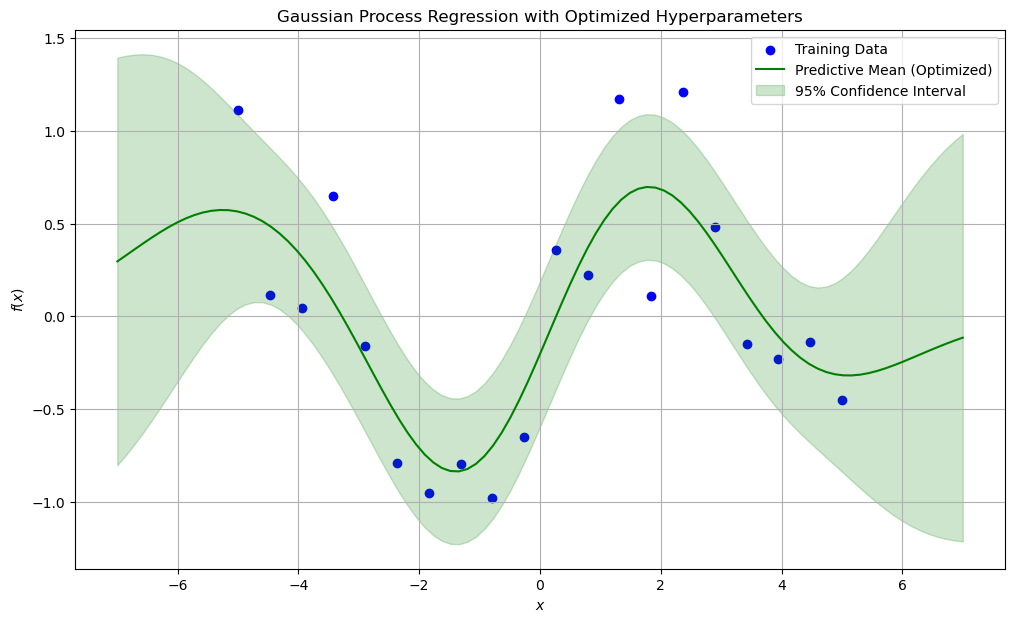

In [59]:
# Compute covariance matrices with optimized hyperparameters
K = squared_exponential_kernel(X_train, X_train, sigma_f_opt, ell_opt)
K += sigma_n_opt**2 * np.eye(len(X_train))
K_s = squared_exponential_kernel(X_train, X_test, sigma_f_opt, ell_opt)
K_ss = squared_exponential_kernel(X_test, X_test, sigma_f_opt, ell_opt)
K_inv = np.linalg.inv(K)

# Compute the posterior predictive mean and covariance
mu_s = K_s.T @ K_inv @ y_train
cov_s = K_ss - K_s.T @ K_inv @ K_s

# Plotting
plt.figure(figsize=(12, 7))

# Plot the training data
plt.scatter(X_train, y_train, color='blue', label='Training Data')

# Plot the predictive mean
plt.plot(X_test, mu_s, color='green', label='Predictive Mean (Optimized)')

# Plot the confidence intervals
stdv = np.sqrt(np.diag(cov_s))
plt.fill_between(
    X_test,
    mu_s - 1.96 * stdv,
    mu_s + 1.96 * stdv,
    alpha=0.2,
    color='green',
    label='95% Confidence Interval'
)

plt.title('Gaussian Process Regression with Optimized Hyperparameters')
plt.xlabel('$x$')
plt.ylabel('$f(x)$')
plt.legend()
plt.grid(True)
plt.show()


### 1. Squared Exponential (RBF) Kernel

As previously discussed, the Squared Exponential kernel is defined as:

$$
k_{\text{SE}}(x, x') = \sigma_f^2 \exp\left(-\frac{(x - x')^2}{2\ell^2}\right)
$$

- **Properties**:
  - Produces infinitely differentiable (very smooth) functions.
  - Assumes function values are strongly correlated over short distances.



### 2. Matérn Kernel

The Matérn kernel is a generalization that allows for controlling the smoothness of the functions.

For $ \nu = \frac{3}{2} $:

$$
k_{\text{Matérn}}(x, x') = \sigma_f^2 \left( 1 + \frac{\sqrt{3}|x - x'|}{\ell} \right) \exp\left(-\frac{\sqrt{3}|x - x'|}{\ell}\right)
$$

- **Properties**:
  - Produces functions that are once differentiable.
  - Offers flexibility between the roughness of the functions (controlled by $ \nu $).

### 3. Periodic Kernel

Useful for modeling periodic functions.

$$
k_{\text{Periodic}}(x, x') = \sigma_f^2 \exp\left(-\frac{2 \sin^2\left(\frac{\pi |x - x'|}{p}\right)}{\ell^2}\right)
$$

- **Parameters**:
  - $ p $: Period of the function.
  - $ \ell $: Controls how quickly the correlation decays.



### 4. Rational Quadratic Kernel

Equivalent to an infinite sum of Squared Exponential kernels with different length-scales.

$$
k_{\text{RQ}}(x, x') = \sigma_f^2 \left( 1 + \frac{(x - x')^2}{2\alpha \ell^2} \right)^{-\alpha}
$$

- **Parameters**:
  - $ \alpha $: Controls the relative weighting of large-scale and small-scale variations.


In [62]:
def matern_kernel(x1, x2, sigma_f=1.0, ell=1.0, nu=1.5):
    """Compute the Matérn kernel between x1 and x2."""
    dists = np.abs(np.subtract.outer(x1, x2))
    if nu == 0.5:
        K = sigma_f**2 * np.exp(-dists / ell)
    elif nu == 1.5:
        sqrt3 = np.sqrt(3)
        K = sigma_f**2 * (1 + sqrt3 * dists / ell) * np.exp(-sqrt3 * dists / ell)
    elif nu == 2.5:
        sqrt5 = np.sqrt(5)
        K = sigma_f**2 * (1 + sqrt5 * dists / ell + 5 * dists**2 / (3 * ell**2)) * np.exp(-sqrt5 * dists / ell)
    else:
        raise ValueError("Unsupported nu value")
    return K


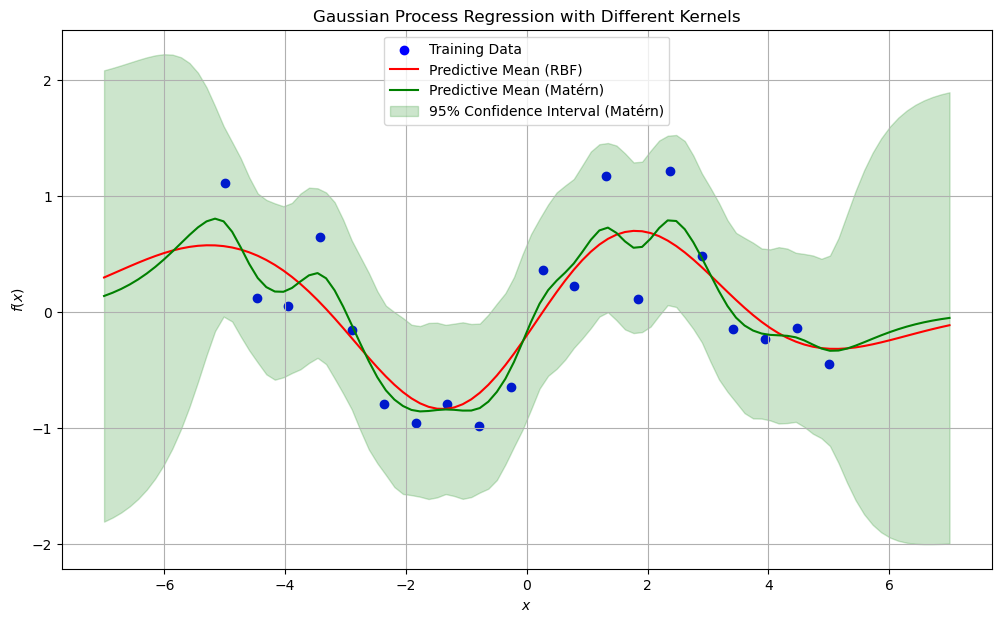

In [64]:
# Using the Matérn kernel with nu=1.5
sigma_f = 1.0
ell = 1.0
sigma_n = 0.5
nu = 1.5

# Compute covariance matrices
K_matern = matern_kernel(X_train, X_train, sigma_f, ell, nu)
K_matern += sigma_n**2 * np.eye(len(X_train))
K_s_matern = matern_kernel(X_train, X_test, sigma_f, ell, nu)
K_ss_matern = matern_kernel(X_test, X_test, sigma_f, ell, nu)
K_inv_matern = np.linalg.inv(K_matern)

# Compute the posterior predictive mean and covariance
mu_s_matern = K_s_matern.T @ K_inv_matern @ y_train
cov_s_matern = K_ss_matern - K_s_matern.T @ K_inv_matern @ K_s_matern

# Plotting
plt.figure(figsize=(12, 7))

# Plot the training data
plt.scatter(X_train, y_train, color='blue', label='Training Data')

# Plot the predictive mean for RBF kernel
plt.plot(X_test, mu_s, color='red', label='Predictive Mean (RBF)')

# Plot the predictive mean for Matérn kernel
plt.plot(X_test, mu_s_matern, color='green', label='Predictive Mean (Matérn)')

# Plot confidence intervals for Matérn kernel
stdv_matern = np.sqrt(np.diag(cov_s_matern))
plt.fill_between(
    X_test,
    mu_s_matern - 1.96 * stdv_matern,
    mu_s_matern + 1.96 * stdv_matern,
    alpha=0.2,
    color='green',
    label='95% Confidence Interval (Matérn)'
)

plt.title('Gaussian Process Regression with Different Kernels')
plt.xlabel('$x$')
plt.ylabel('$f(x)$')
plt.legend()
plt.grid(True)
plt.show()


###### Expresiones obtenidas para dos kernels distintos.

## Kernel Combination Rules

Complex functions often exhibit multiple properties, such as periodicity combined with smooth trends. Gaussian Processes allow us to build custom kernels by combining simpler kernels.



### Combining Kernels

Kernels can be combined using addition and multiplication to capture multiple characteristics:

- **Addition ($ k = k_1 + k_2 $)**:
  - Models where the function is assumed to be the sum of independent functions.
  - The resulting covariance is the sum of the individual covariances.

- **Multiplication ($ k = k_1 \times k_2 $)**:
  - Models where the function's properties are jointly influenced by the combined kernels.
  - The resulting covariance captures interactions between kernels.

#### Example: Periodic Plus Linear Trend

Suppose we have data that shows periodic behavior with a linear trend. We can model this using:

- **Periodic Kernel** $ k_{\text{Periodic}} $
- **Linear Kernel**:

$$
k_{\text{Linear}}(x, x') = \sigma_b^2 + \sigma_v^2 (x - c)(x' - c)
$$



In [ ]:
# Generate synthetic data with a periodic pattern and a linear trend
np.random.seed(42)
X_train = np.linspace(0, 10, 50)
y_train = 0.5 * X_train + np.sin(2 * np.pi * X_train / 5) + np.random.normal(0, 0.5, size=X_train.shape)

# Plot the training data
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='blue', label='Training Data')
plt.title('Training Data with Periodic Behavior and Linear Trend')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.legend()
plt.grid(True)
plt.show()


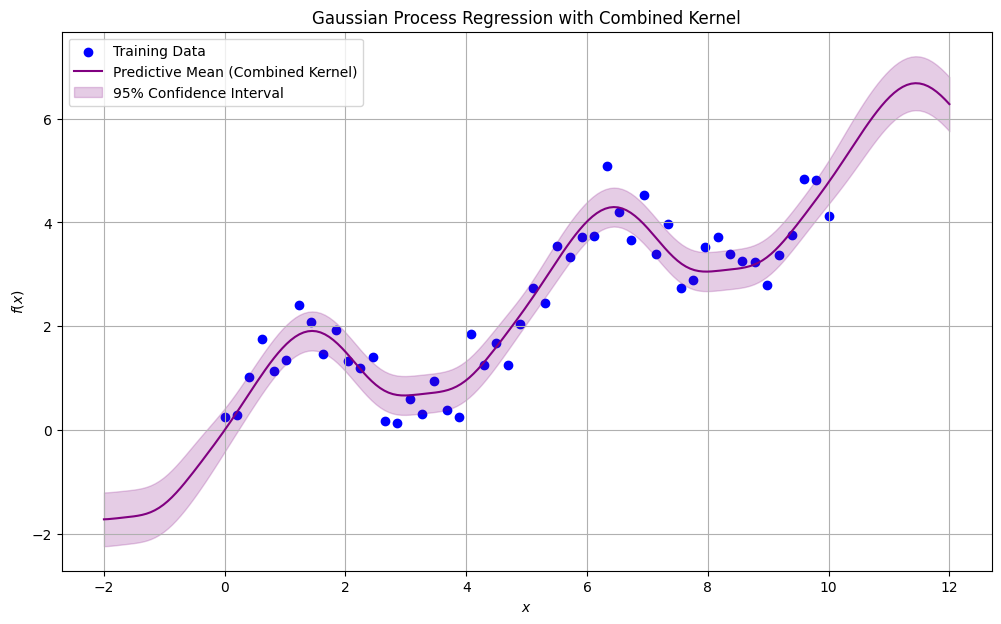

In [93]:
# Define the Linear Kernel
def linear_kernel(x1, x2, sigma_b=0, sigma_v=1, c=0):
    """Compute the Linear kernel between x1 and x2."""
    # Compute the outer product of (x1 - c) and (x2 - c)
    return sigma_b**2 + sigma_v**2 * np.outer(x1 - c, x2 - c)

# Define the Periodic Kernel
def periodic_kernel(x1, x2, sigma_f=1.0, ell=1.0, p=1.0):
    """Compute the Periodic kernel between x1 and x2."""
    sin_sq = np.sin(np.pi * np.subtract.outer(x1, x2) / p) ** 2
    return sigma_f**2 * np.exp(-2 * sin_sq / ell**2)

# Combined Kernel Function
def combined_kernel(x1, x2):
    return periodic_kernel(x1, x2, sigma_f, ell, p) + linear_kernel(x1, x2, sigma_b, sigma_v)

# Hyperparameters
sigma_f = 1.0   # Signal variance for periodic kernel
ell = 1.0       # Length-scale for periodic kernel
p = 5.0         # Period of the periodic kernel
sigma_b = 0.0   # Bias parameter for linear kernel
sigma_v = 1.0   # Variance parameter for linear kernel
sigma_n = 0.5   # Noise standard deviation

# Generate synthetic data
np.random.seed(42)
X_train = np.linspace(0, 10, 50)
y_train = 0.5 * X_train + np.sin(2 * np.pi * X_train / 5) + np.random.normal(0, 0.5, size=X_train.shape)

# Test inputs
X_test = np.linspace(-2, 12, 200)

# Compute covariance matrices
K_combined = combined_kernel(X_train, X_train) + sigma_n**2 * np.eye(len(X_train))
K_s_combined = combined_kernel(X_train, X_test)
K_ss_combined = combined_kernel(X_test, X_test)
K_inv_combined = np.linalg.inv(K_combined)

# Compute the posterior predictive mean and covariance. Es lo mismo que antes pero con el combinado
mu_s_combined = K_s_combined.T @ K_inv_combined @ y_train
cov_s_combined = K_ss_combined - K_s_combined.T @ K_inv_combined @ K_s_combined

# Plotting
plt.figure(figsize=(12, 7))

# Plot the training data
plt.scatter(X_train, y_train, color='blue', label='Training Data')

# Plot the predictive mean
plt.plot(X_test, mu_s_combined, color='purple', label='Predictive Mean (Combined Kernel)')

# Plot the confidence intervals
stdv_combined = np.sqrt(np.diag(cov_s_combined))
plt.fill_between(
    X_test,
    mu_s_combined - 1.96 * stdv_combined,
    mu_s_combined + 1.96 * stdv_combined,
    alpha=0.2,
    color='purple',
    label='95% Confidence Interval'
)

plt.title('Gaussian Process Regression with Combined Kernel')
plt.xlabel('$x$')
plt.ylabel('$f(x)$')
plt.legend()
plt.grid(True)
plt.show()


### Hyperparameter Optimization with Combined Kernels
We can extend hyperparameter tuning to combined kernels by optimizing all hyperparameters jointly.

In [ ]:
# Define the log marginal likelihood for the combined kernel
def log_marginal_likelihood_combined(theta):
    sigma_f, ell, p, sigma_b, sigma_v, sigma_n = theta
    # Update the kernel functions with new hyperparameters
    def combined_kernel_opt(x1, x2):
        return (
            periodic_kernel(x1, x2, sigma_f, ell, p) +
            linear_kernel(x1, x2, sigma_b, sigma_v)
        )
    K = combined_kernel_opt(X_train, X_train) + sigma_n**2 * np.eye(len(X_train))
    try:
        L = np.linalg.cholesky(K)
    except np.linalg.LinAlgError:
        return np.inf  # Return infinity if K is not positive definite
    alpha = np.linalg.solve(L.T, np.linalg.solve(L, y_train))
    log_likelihood = -0.5 * y_train.T @ alpha
    log_likelihood -= np.sum(np.log(np.diag(L)))
    log_likelihood -= len(X_train) / 2 * np.log(2 * np.pi)
    return -log_likelihood

# Initial guesses for hyperparameters
initial_theta = [1.0, 1.0, 5.0, 0.0, 1.0, 0.5]  # sigma_f, ell, p, sigma_b, sigma_v, sigma_n

# Bounds to ensure positive hyperparameters
bounds = [(1e-5, None)] * 6

# Optimize
result = minimize(
    fun=log_marginal_likelihood_combined,
    x0=initial_theta,
    bounds=bounds,
    method='L-BFGS-B'
)

# Extract optimized hyperparameters
sigma_f_opt, ell_opt, p_opt, sigma_b_opt, sigma_v_opt, sigma_n_opt = result.x

# Update the combined kernel with optimized hyperparameters
def combined_kernel_opt(x1, x2):
    return (
        periodic_kernel(x1, x2, sigma_f_opt, ell_opt, p_opt) +
        linear_kernel(x1, x2, sigma_b_opt, sigma_v_opt)
    )

# Recompute covariance matrices
K_combined = combined_kernel_opt(X_train, X_train) + sigma_n_opt**2 * np.eye(len(X_train))
K_s_combined = combined_kernel_opt(X_train, X_test)
K_ss_combined = combined_kernel_opt(X_test, X_test)
K_inv_combined = np.linalg.inv(K_combined)

# Compute the posterior predictive mean and covariance
mu_s_combined = K_s_combined.T @ K_inv_combined @ y_train
cov_s_combined = K_ss_combined - K_s_combined.T @ K_inv_combined @ K_s_combined

# Plotting
plt.figure(figsize=(12, 7))

# Plot the training data
plt.scatter(X_train, y_train, color='blue', label='Training Data')

# Plot the predictive mean
plt.plot(X_test, mu_s_combined, color='purple', label='Predictive Mean (Combined Kernel)')

# Plot the confidence intervals
stdv_combined = np.sqrt(np.diag(cov_s_combined))
plt.fill_between(
    X_test,
    mu_s_combined - 1.96 * stdv_combined,
    mu_s_combined + 1.96 * stdv_combined,
    alpha=0.2,
    color='purple',
    label='95% Confidence Interval'
)

plt.title('Gaussian Process Regression with Combined Kernel')
plt.xlabel('$x$')
plt.ylabel('$f(x)$')
plt.legend()
plt.grid(True)
plt.show()

# Exercises
## Exercise 1: Implementing the Rational Quadratic Kernel

Implement the Rational Quadratic (RQ) kernel and compare GP regression results using the RQ kernel with those using the Squared Exponential (RBF) kernel.

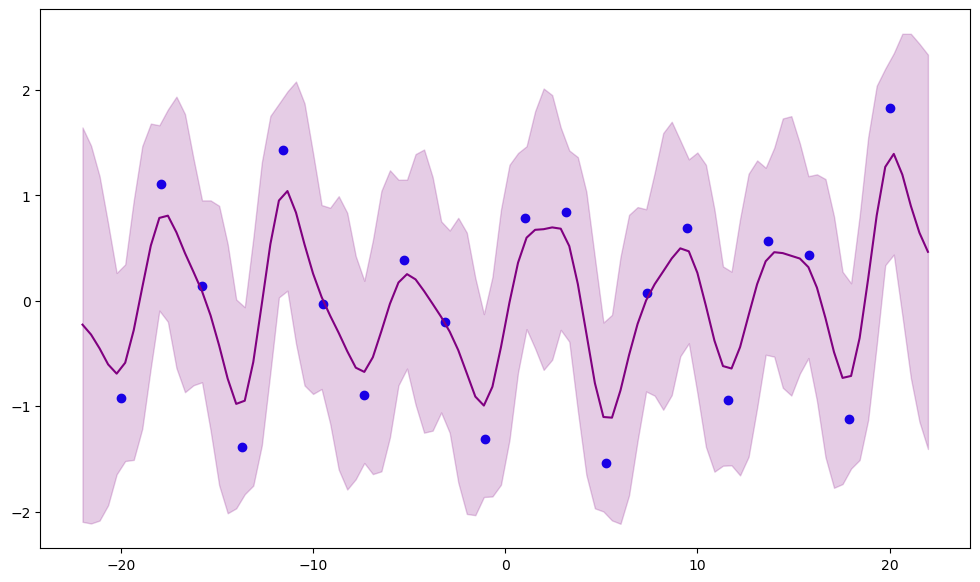

In [78]:
import numpy as np
import matplotlib.pyplot as plt

# Function to model
def f(x):
    return np.sin(x)

# Training data
X_train = np.linspace(-20, 20, 20)
y_train = f(X_train) + np.random.normal(0, 0.5, size=X_train.shape)

# Test inputs
X_test = np.linspace(-22, 22, 100)

# Implement the Rational Quadratic Kernel
def rational_quadratic_kernel(x1, x2, sigma_f=1.0, ell=1.0, alpha=1.0):
    sqdist = np.subtract.outer(x1, x2)**2
    return sigma_f**2*(1+sqdist/(2*alpha*ell**2))**(-alpha)
    

# Hyperparameters
sigma_f = 1.0
ell = 1.0
alpha = 1.0
sigma_n = 0.5


# Compute covariance matrices using the RQ kernel
K_rq = rational_quadratic_kernel(X_train,X_train, sigma_f, ell, alpha)
K_rq += sigma_n**2 * np.eye(len(X_train))
K_s_rq = rational_quadratic_kernel(X_train, X_test, sigma_f, ell, alpha)
K_ss_rq = rational_quadratic_kernel(X_test, X_test, sigma_f, ell, alpha)
K_inv_rq = np.linalg.inv(K_rq)

# Compute the posterior predictive mean and covariance
mu_s_rq = K_s_rq.T@K_inv_rq@y_train
cov_s_rq = K_ss_rq-K_s_rq .T@K_inv_rq@K_s_rq

# Plotting
plt.figure(figsize=(12, 7))

# Plot the training data
plt.scatter(X_train, y_train, color='blue', label='Training Data')

# Plot the predictive mean for RQ kernel
plt.plot(X_test, mu_s_rq, color='purple', label='Predictive Mean (RQ Kernel)')

# Plot confidence intervals for RQ kernel
stdv_rq = np.sqrt(np.diag(cov_s_rq))
plt.fill_between(
    X_test,
    mu_s_rq - 1.96 * stdv_rq,
    mu_s_rq + 1.96 * stdv_rq,
    alpha=0.2,
    color='purple',
    label='95% Confidence Interval (RQ Kernel)'
)


## Exercise 2: Hyperparameter Optimization with Bounds and Priors

Modify the hyperparameter optimization to include bounds and priors on hyperparameters with the RBF kernel. Use the scipy.optimize.minimize function with constraints.

Optimized sigma_f: 0.8609720288993608
Optimized ell: 0.7243045931556064
Optimized sigma_n: 0.4923040446820132


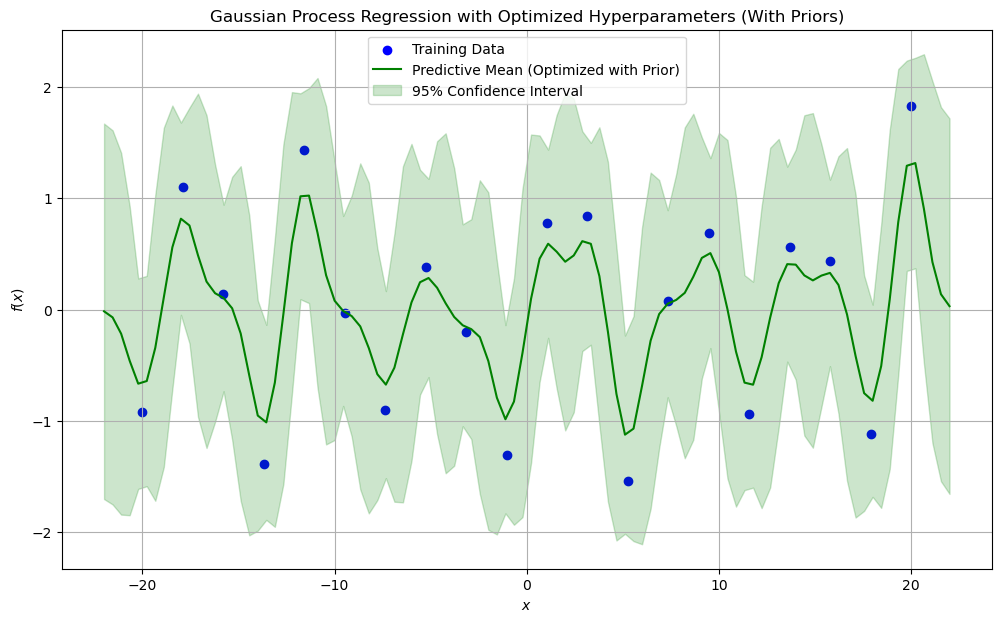

In [83]:
from scipy.optimize import minimize

# Define log marginal likelihood function
def log_marginal_likelihood(theta):
    """Compute the log marginal likelihood for given hyperparameters."""
    sigma_f, ell, sigma_n = theta
    K = squared_exponential_kernel(X_train, X_train, sigma_f, ell) + sigma_n**2 * np.eye(len(X_train))
    try:
        L = np.linalg.cholesky(K)
    except np.linalg.LinAlgError:
        return np.inf  # Return infinity if K is not positive definite
    
    # Solve for alpha: K * alpha = y
    alpha = np.linalg.solve(L.T, np.linalg.solve(L, y_train))
    
    # Compute the log marginal likelihood
    log_likelihood = -0.5 * y_train.T @ alpha
    log_likelihood -= np.sum(np.log(np.diag(L)))
    log_likelihood -= len(X_train) / 2 * np.log(2 * np.pi)
    
    # We return the negative log marginal likelihood for minimization
    return -log_likelihood

# Define the prior penalty function
def prior_penalty(theta):
    sigma_f, ell, sigma_n = theta
    # Assume prior means and variances
    mu_sigma_f, mu_ell, mu_sigma_n = 1.0, 1.0, 0.5
    sigma_sigma_f, sigma_ell, sigma_sigma_n = 0.5, 0.5, 0.2
    # Negative log prior probabilities (penalties)
    penalty = (
        0.5 * ((sigma_f - mu_sigma_f) / sigma_sigma_f) ** 2 +
        0.5 * ((ell - mu_ell) / sigma_ell) ** 2 +
        0.5 * ((sigma_n - mu_sigma_n) / sigma_sigma_n) ** 2
    )
    return penalty

# Modify the log marginal likelihood to include the prior penalty
def log_marginal_likelihood_with_prior(theta):
    # Your code here
    lml = log_marginal_likelihood(theta)
    penalty = prior_penalty(theta)
    return lml + penalty  # Add penalty to the negative log marginal likelihood

# Initial guesses for hyperparameters
initial_theta = [1.0, 1.0, 0.5]  # sigma_f, ell, sigma_n

# Bounds for hyperparameters
bounds = ((1e-2, 5.0), (1e-2, 5.0), (1e-2, 1.0))

# Optimize
# Bounds to ensure positive hyperparameters

# Optimize
result = minimize(
    fun = log_marginal_likelihood_with_prior,
    x0 = initial_theta,
    bounds = bounds,
    method = 'L-BFGS-B'
)

# Extract optimized hyperparameters and retrain GP
sigma_f_opt, ell_opt, sigma_n_opt = result.x
print(f"Optimized sigma_f: {sigma_f_opt}")
print(f"Optimized ell: {ell_opt}")
print(f"Optimized sigma_n: {sigma_n_opt}")

# Compute covariance matrices with optimized hyperparameters
K = squared_exponential_kernel(X_train, X_train, sigma_f_opt, ell_opt)
K += sigma_n_opt**2 * np.eye(len(X_train))
K_s = squared_exponential_kernel(X_train, X_test, sigma_f_opt, ell_opt)
K_ss = squared_exponential_kernel(X_test, X_test, sigma_f_opt, ell_opt)
K_inv = np.linalg.inv(K)

# Compute the posterior predictive mean and covariance
mu_s = K_s.T @ K_inv @ y_train
cov_s = K_ss - K_s.T @ K_inv @ K_s

# Plotting
plt.figure(figsize=(12, 7))

# Plot the training data
plt.scatter(X_train, y_train, color='blue', label='Training Data')

# Plot the predictive mean
plt.plot(X_test, mu_s, color='green', label='Predictive Mean (Optimized with Prior)')

# Plot the confidence intervals
stdv = np.sqrt(np.diag(cov_s))
plt.fill_between(
    X_test,
    mu_s - 1.96 * stdv,
    mu_s + 1.96 * stdv,
    alpha=0.2,
    color='green',
    label='95% Confidence Interval'
)

plt.title('Gaussian Process Regression with Optimized Hyperparameters (With Priors)')
plt.xlabel('$x$')
plt.ylabel('$f(x)$')
plt.legend()
plt.grid(True)
plt.show()



## Exercise 3: Gaussian Processes with Multidimensional Inputs

Extend the GP regression implementation to handle multidimensional input data. Update the kernel functions to compute the pairwise distances between multidimensional inputs. El kernel pasa a ser bidimensional si pasaramos a tener tres variables.

Significado de X1[:, None, :] - X2[None, :, :]:

- La primera dimensión es el índice de los puntos en X1.
- La segunda dimensión es el índice de los puntos en X2.
- La tercera dimensión corresponde a las diferencias entre las coordenadas en el espacio de entrada.

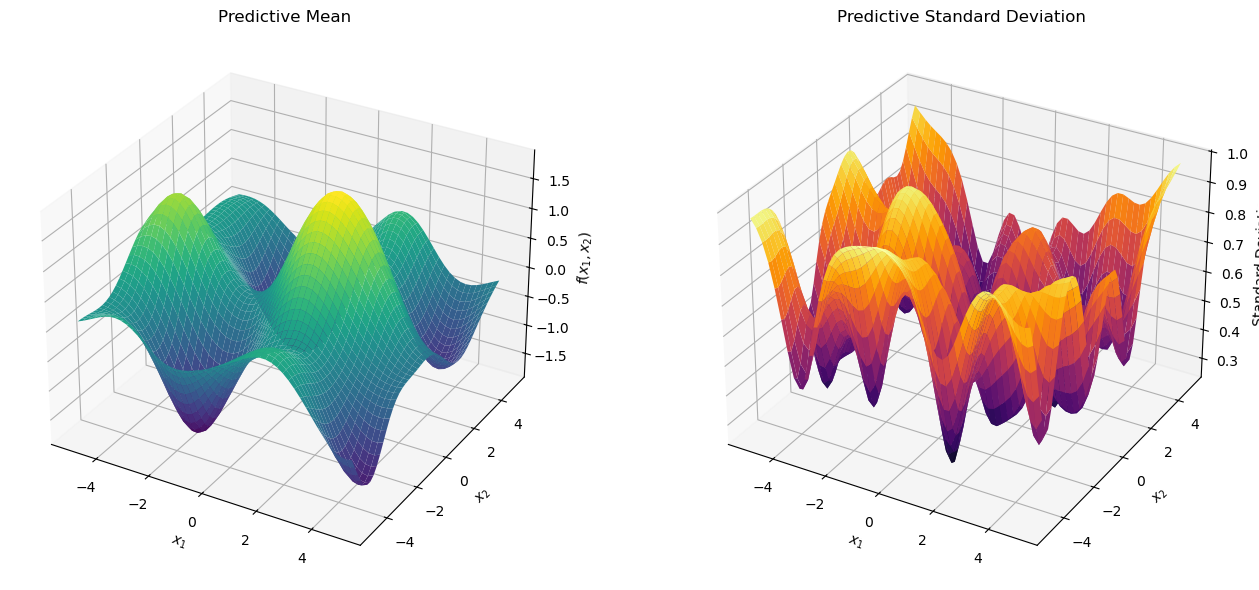

In [89]:
import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic 2D data
def f(X):
    """Function to model: f(x1, x2) = sin(x1) + cos(x2)"""
    return np.sin(X[:, 0]) + np.cos(X[:, 1])

# Training data
n_train = 50
X_train = np.random.uniform(-5, 5, (n_train, 2))
y_train = f(X_train) + np.random.normal(0, 0.1, size=n_train)

# Test inputs (create a grid for visualization)
x1_test = np.linspace(-5, 5, 50)
x2_test = np.linspace(-5, 5, 50)
X1_test, X2_test = np.meshgrid(x1_test, x2_test)
X_test = np.column_stack([X1_test.ravel(), X2_test.ravel()])

# Modify the Squared Exponential Kernel to handle 2D inputs
def squared_exponential_kernel(X1, X2, sigma_f=1.0, ell=1.0):
    """Compute the RBF kernel between two sets of vectors."""
    sqdist = np.sum((X1[:, None, :] - X2[None, :, :]) ** 2, axis=2)
    return sigma_f**2 * np.exp(-0.5 * sqdist / ell**2)

# Hyperparameters
sigma_f = 1.0
ell = 1.0
sigma_n = 0.1

# Compute covariance matrices with optimized hyperparameters
K = squared_exponential_kernel(X_train, X_train, sigma_f, ell)
K += sigma_n_opt**2 * np.eye(len(X_train))
K_s = squared_exponential_kernel(X_train, X_test, sigma_f, ell)
K_ss = squared_exponential_kernel(X_test, X_test, sigma_f, ell)
K_inv = np.linalg.inv(K)


# Compute the posterior predictive mean and covariance
mu_s = K_s.T @ K_inv @ y_train
cov_s = K_ss - K_s.T @ K_inv @ K_s

# Reshape results for plotting
mu_s = mu_s.reshape(X1_test.shape)
stdv = np.sqrt(np.diag(cov_s)).reshape(X1_test.shape)
# Plotting the predictive mean as a surface plot
fig = plt.figure(figsize=(14, 6))

# Predictive mean
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(X1_test, X2_test, mu_s, cmap='viridis', edgecolor='none')
ax1.set_title('Predictive Mean')
ax1.set_xlabel('$x_1$')
ax1.set_ylabel('$x_2$')
ax1.set_zlabel('$f(x_1, x_2)$')

# Uncertainty (standard deviation)
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(X1_test, X2_test, stdv, cmap='inferno', edgecolor='none')
ax2.set_title('Predictive Standard Deviation')
ax2.set_xlabel('$x_1$')
ax2.set_ylabel('$x_2$')
ax2.set_zlabel('Standard Deviation')

plt.tight_layout()
plt.show()


## Exercise 4: Kernel Combination

Design a custom kernel that models a function with a periodic component modulated by an exponential decay (e.g., multiplicative combination of the Periodic and exponential kernels). This kernel is given by the formula:

$$
k_{\text{Custom}}(x, x') = k_{\text{Periodic}}(x, x') \times k_{\text{Exp}}(x, x')
$$

where $ k_{\text{Periodic}} $ is the Periodic kernel with formula:

$$
k_{\text{Periodic}}(x, x') = \sigma_f^2 \exp\left(-\frac{2 \sin^2\left(\frac{\pi |x - x'|}{p}\right)}{\ell^2}\right)
$$

and $ k_{\text{Exp}} $ is the Exponential kernel with formula:

$$
k_{\text{Exp}}(x, x') = \sigma_f^2 \exp\left(-\frac{|x - x'|}{\ell}\right)
$$

Implement the custom kernel and use it for GP regression on synthetic data.

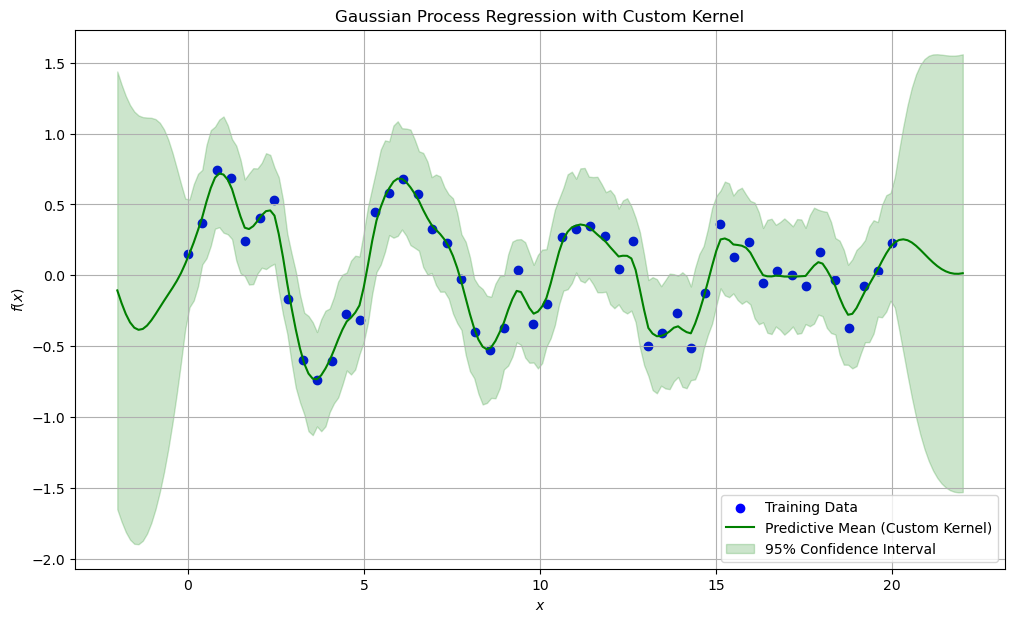

In [105]:
import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic data with periodic and decaying behavior
def f(x):
    return np.sin(2 * np.pi * x / 5) * np.exp(-0.1 * x)

# Training data
X_train = np.linspace(0, 20, 50)
y_train = f(X_train) + np.random.normal(0, 0.2, size=X_train.shape)

# Test inputs
X_test = np.linspace(-2, 22, 200)

# Define the custom kernel
def custom_kernel(x1, x2, sigma_f=1.0, ell=1.0, p=5.0, decay_rate=1.0):
    """Custom kernel: Decaying periodic kernel."""
    # Periodic Kernel
    # Cuidado con el substract.outer
    sin_sq = np.sin(np.pi * np.subtract.outer(x1, x2) / p) ** 2
    K_periodic = sigma_f**2*np.exp((-2*sin_sq)/ell**2)
    # Exponential Decay Kernel
    abs_diff = np.abs(np.subtract.outer(x1, x2))
    K_decay = np.exp(-abs_diff*decay_rate)
    # Combined Kernel (Multiplication)
    return K_periodic * K_decay

# Hyperparameters
sigma_f = 1.0
ell = 1.0
p = 5.0
decay_rate = 0.1
sigma_n = 0.2

### Mucho cuidado con los parámetros que se le pasan a cada función.
# Compute covariance matrices
K_custom = custom_kernel(X_train, X_train, sigma_f, ell, p, decay_rate)
K_custom += sigma_n**2 * np.eye(len(X_train))
K_s_custom = custom_kernel(X_train, X_test, sigma_f, ell, p, decay_rate)
K_ss_custom = custom_kernel(X_test, X_test, sigma_f, ell, p, decay_rate)
K_inv_custom = np.linalg.inv(K_custom)

# Compute the posterior predictive mean and covariance
mu_s_custom = K_s_custom.T @ K_inv_custom @ y_train
cov_s_custom = K_ss_custom - K_s_custom.T @ K_inv_custom @ K_s_custom

# Plotting
plt.figure(figsize=(12, 7))

# Plot the training data
plt.scatter(X_train, y_train, color='blue', label='Training Data')

# Plot the predictive mean
plt.plot(X_test, mu_s_custom, color='green', label='Predictive Mean (Custom Kernel)')

# Plot the confidence intervals
stdv_custom = np.sqrt(np.diag(cov_s_custom))
plt.fill_between(
    X_test,
    mu_s_custom - 1.96 * stdv_custom,
    mu_s_custom + 1.96 * stdv_custom,
    alpha=0.2,
    color='green',
    label='95% Confidence Interval'
)

plt.title('Gaussian Process Regression with Custom Kernel')
plt.xlabel('$x$')
plt.ylabel('$f(x)$')
plt.legend()
plt.grid(True)
plt.show()
